# Semantic segmentation on the CelebAMask-HQ dataset (https://github.com/switchablenorms/CelebAMask-HQ)

Let us establish a GPU runtime, for computational reasons.

In [ ]:
import torch
if torch.cuda.is_available():
    !nvidia-smi
else:
    print("NO GPU :( )")

Tue Apr 21 13:20:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Loading the dataset from the zip archive
I downloaded the dataset from Github, then implemented a zip extraction of the dataset + anonical split into train/test/val.

In [ ]:
import os
import hashlib
import zipfile
import numpy as np
from PIL import Image

import torch
import torch.utils.data


#All semantic part labels in CelebAMask-HQ and their integer class IDs.
# class 0 is reserved for "background" (no part mask present).
MASK_PARTS = [
    "skin",       # 1
    "l_brow",     # 2
    "r_brow",     # 3
    "l_eye",      # 4
    "r_eye",      # 5
    "eye_g",      # 6
    "l_ear",      # 7
    "r_ear",      # 8
    "ear_r",      # 9
    "nose",       # 10
    "mouth",      # 11
    "u_lip",      # 12
    "l_lip",      # 13
    "neck",       # 14
    "neck_l",     # 15
    "cloth",      # 16
    "hair",       # 17
    "hat",        # 18
]
PART_TO_CLASS = {part: idx + 1 for idx, part in enumerate(MASK_PARTS)}
NUM_CLASSES = len(MASK_PARTS) + 1  # including background


class CelebAMaskHQDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for CelebAMask-HQ.

    Expected zip layout (as downloaded from the official GitHub repo):
        CelebAMask-HQ/
            CelebA-HQ-img/          ← 30 000 JPEG face images  (000000.jpg …)
            CelebAMask-HQ-mask-anno/
                0/                  ← masks for images 0–1 999
                1/                  ← masks for images 2 000–3 999
                …
                14/                 ← masks for images 28 000–29 999
            CelebA-HQ-to-CelebA-mapping.txt

    Each mask subfolder contains files named  <5-digit-index>_<part>.png
    (binary PNG, 512×512).  We merge all part masks for one image into a
    single integer label map (H×W) where pixel value = class ID (0 = bg).

    Args:
        base_folder (str):  Root directory that contains (or will contain) the
                            extracted dataset.
        zip_path (str):     Path to the downloaded .zip archive.
                            Pass None to skip extraction.
        transforms (callable, optional): Applied to (image, mask) pair.
                            Expected signature: transforms(image, mask) → (image, mask).
        split (str):        One of 'train', 'val', 'test', or 'all'.
        extract (bool):     Extract the zip if not already done.
    """

    SPLIT_MAP = {"train": 0, "val": 1, "test": 2}

    def __init__(
        self,
        base_folder: str,
        zip_path: str = None,
        transforms=None,
        split: str = "train",
        extract: bool = True,
    ):
        super().__init__()
        self.base_folder = os.path.expanduser(base_folder)
        self.transforms = transforms

        if extract and zip_path is not None:
            self._extract_zip(zip_path, self.base_folder)

        # After extraction the data sits one level deeper.
        self.dataset_root = os.path.join(self.base_folder, "CelebAMask-HQ")
        self._verify_structure()

        self.image_dir = os.path.join(self.dataset_root, "CelebA-HQ-img")
        self.mask_dir  = os.path.join(self.dataset_root, "CelebAMask-HQ-mask-anno")

        # Build index list according to the requested split.
        self.indices = self._load_split(split)



    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        img_idx = self.indices[idx]

        image = self._load_image(img_idx)
        mask  = self._load_mask(img_idx)

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

    # Private helpers

    def _load_image(self, img_idx: int) -> Image.Image:
        filename = f"{img_idx}.jpg"
        path = os.path.join(self.image_dir, filename)
        return Image.open(path).convert("RGB")

    def _load_mask(self, img_idx: int) -> Image.Image:
        """
        Merge all per-part binary masks for *img_idx* into one integer
        label map (H×W uint8).  Later parts overwrite earlier ones where
        they overlap (overlaps are rare in practice).
        """
        # Each group-folder covers 2 000 images.
        group = img_idx // 2000
        mask_subdir = os.path.join(self.mask_dir, str(group))

        # Start with an all-zero (background) canvas.
        # We peek at the first available mask to get spatial dimensions,
        # falling back to 512×512 which is the canonical CelebAMask-HQ size.
        h, w = 512, 512
        label_map = np.zeros((h, w), dtype=np.uint8)

        for part, class_id in PART_TO_CLASS.items():
            part_path = os.path.join(mask_subdir, f"{img_idx:05d}_{part}.png")
            if not os.path.isfile(part_path):
                continue  # this part simply does not exist for this image
            part_mask = np.array(Image.open(part_path).convert("L"))
            # Binary mask: any non-zero pixel belongs to this part.
            label_map[part_mask > 0] = class_id

        return Image.fromarray(label_map)

    def _load_split(self, split: str) -> list:
      """
      Returns a sorted list of image indices belonging to *split*.

      Because list_eval_partition.txt and the CelebA-HQ mapping file are
      often absent from redistributed zips, we fall back to the canonical
      index-based partition used in the original CelebAMask-HQ paper:

          train : indices   0 – 27 999  (28 000 images)
          val   : indices  28 000 – 28 999  (1 000 images)
          test  : indices  29 000 – 29 999  (1 000 images)
      """
      if split == "all":
          return list(range(30000))

      #canonical index-based split

      ranges = {
          "train": range(0,     28_000),
          "val":   range(28_000, 29_000),
          "test":  range(29_000, 30_000),
      }
      return list(ranges[split])

    def _verify_structure(self) -> None:
        expected_dirs = [
            os.path.join(self.dataset_root, "CelebA-HQ-img"),
            os.path.join(self.dataset_root, "CelebAMask-HQ-mask-anno"),
        ]
        for d in expected_dirs:
            if not os.path.isdir(d):
                raise FileNotFoundError(
                    f"Expected directory not found: {d}\n"
                    "Make sure the zip was extracted correctly and that "
                    "'base_folder' points to the right location."
                )

    # Zip extraction

    def _extract_zip(self, zip_path: str, dest_folder: str) -> None:
        """Extract *zip_path* into *dest_folder* (skips if already done)."""
        marker = os.path.join(dest_folder, "CelebAMask-HQ")
        if os.path.isdir(marker):
            print(f"Dataset already extracted at '{marker}'. Skipping extraction.")
            return

        os.makedirs(dest_folder, exist_ok=True)
        zip_path = os.path.expanduser(zip_path)

        if not os.path.isfile(zip_path):
            raise FileNotFoundError(
                f"Zip archive not found: {zip_path}\n"
                "Download the dataset from "
                "https://github.com/switchablenorms/CelebAMask-HQ and pass "
                "the local path via 'zip_path'."
            )

        print(f"Extracting '{zip_path}' → '{dest_folder}' …")
        with zipfile.ZipFile(zip_path, "r") as zf:
            members = zf.infolist()
            for i, member in enumerate(members, 1):
                zf.extract(member, dest_folder)
                if i % 5000 == 0 or i == len(members):
                    print(f"  {i}/{len(members)} files extracted", end="\r")
        print("\nExtraction complete.")

    # Optional: MD5 integrity check (same helper as original)

    @staticmethod
    def _compute_md5(filepath: str, chunk_size: int = 1024 * 1024) -> str:
        with open(filepath, "rb") as f:
            md5 = hashlib.md5()
            while chunk := f.read(chunk_size):
                md5.update(chunk)
        return md5.hexdigest()

    @staticmethod
    def check_integrity(filepath: str, md5: str) -> bool:
        if not os.path.isfile(filepath):
            return False
        return CelebAMaskHQDataset._compute_md5(filepath) == md5


Now we use the zip extraction and dataset loading so as to prepare a training subset for the following section (vizualization of the dataset and different geometric transformations).

In [ ]:
    import torchvision.transforms.functional as TF

    def paired_transforms(image, mask):
        """Minimal example: resize both image and mask to 256×256."""
        image = TF.resize(image, (256, 256))
        mask  = TF.resize(mask,  (256, 256), interpolation=Image.NEAREST)
        image = TF.to_tensor(image)                        # (3, H, W)  float
        mask  = torch.from_numpy(np.array(mask)).long()    # (H, W)     int64
        return image, mask

    dataset = CelebAMaskHQDataset(
        base_folder="celeba_mask_hq",
        zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",   #path to downloaded zip
        transforms=paired_transforms,
        split="train",
        extract=True,
    )

    # We do not need test & val subsets yet

    # dataset_test = CelebAMaskHQDataset(
    #     base_folder="celeba_mask_hq",
    #     zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",   #path to downloaded zip
    #     transforms=paired_transforms,
    #     split="test",
    #     extract=True,
    # )

    # dataset_val = CelebAMaskHQDataset(
    #     base_folder="celeba_mask_hq",
    #     zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",   #path to downloaded zip
    #     transforms=paired_transforms,
    #     split="val",
    #     extract=True,
    # )

    print(f"Train split size : {len(dataset)}")
    # print(f"Test split size : {len(dataset_test)}")
    # print(f"Val split size : {len(dataset_val)}")

    img, msk = dataset[0]
    print(f"Image tensor     : {img.shape}  dtype={img.dtype}")
    print(f"Mask tensor      : {msk.shape}  dtype={msk.dtype}")
    print(f"Unique class IDs : {msk.unique().tolist()}")

Iterating over the dataset to see some images

0 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


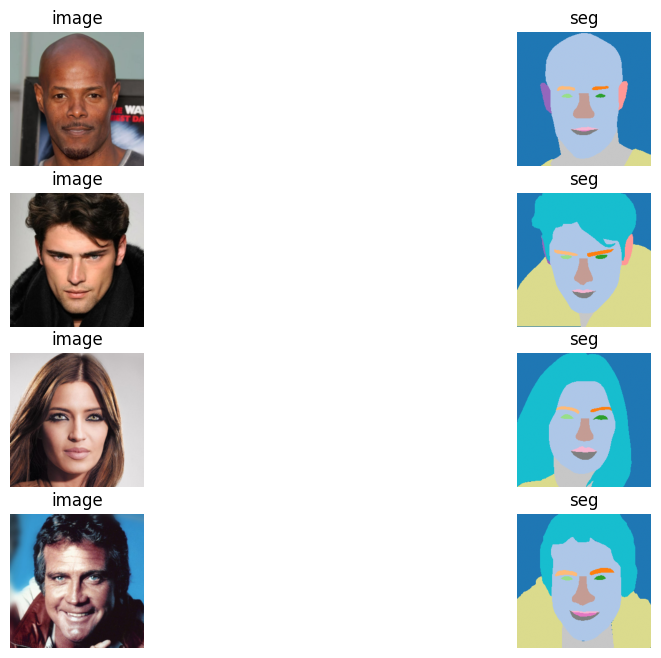

1 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


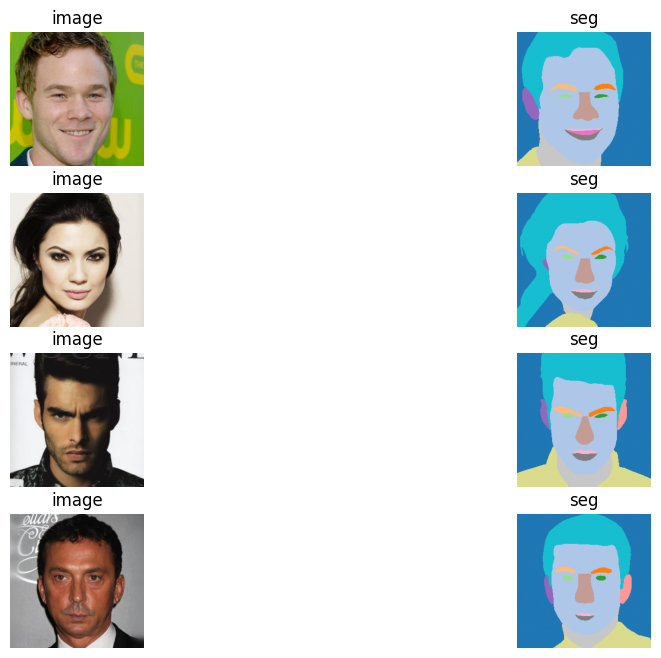

2 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


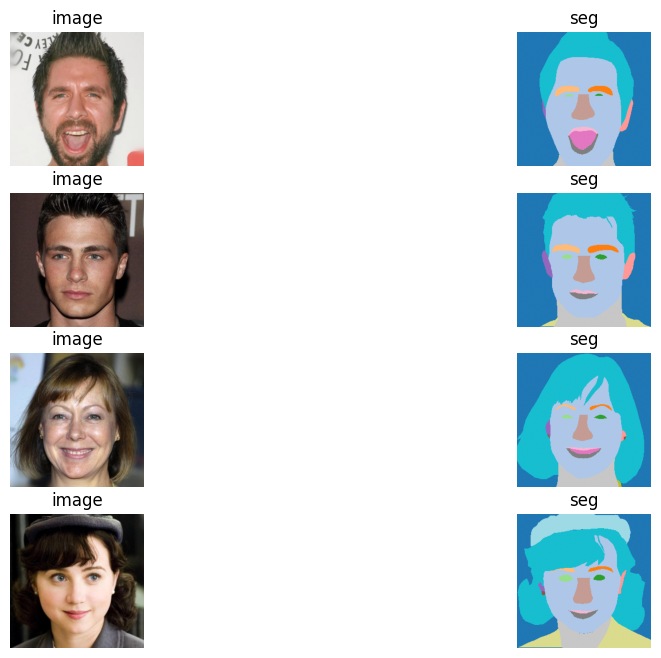

In [ ]:
import matplotlib.pyplot as plt

# let's create a DataLoader to easily iterate over this dataset
bs = 4
dataloader = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=True, num_workers=0)


for i_batch, sample_batched in enumerate(dataloader):
    imgs = sample_batched[0]
    segs = sample_batched[1]
    print(i_batch, imgs.size(), segs.size())


    rows, cols = bs, 2
    figure = plt.figure(figsize=(bs*3, bs*2))
    for i in range(0, bs):
        figure.add_subplot(rows, cols, 2*i+1)
        plt.title('image')
        plt.axis("off")
        plt.imshow(imgs[i].permute(1, 2, 0).numpy())


        figure.add_subplot(rows, cols, 2*i+2)
        plt.title('seg')
        plt.axis("off")
        plt.imshow(segs[i].numpy(), cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.show()
    # display the first 3 batches
    if i_batch == 2:
      break

## Geometric rotation, let us try some transformations and visualize the images

In [ ]:
import random
import numpy as np
from PIL import Image
import torch
import torch.utils.data
import torchvision.transforms.functional as TF
import torchvision.transforms.v2 as T
from torchvision import tv_tensors

# 1.From scratch
# Manually sample one random value per operation and apply it to both inputs.
# No library magic: the pairing is explicit in the code.

class PairedGeometricAugmentation:
    """
    Paired geometric augmentation implemented from scratch.

    The core contract: every random parameter is sampled ONCE and then
    applied identically to the image and the mask.  The mask always uses
    NEAREST interpolation so integer class IDs are never blended.
    """

    def __init__(
        self,
        hflip_p: float = 0.5,
        vflip_p: float = 0.1,
        rotation_degrees: float = 20.0,
        crop_scale: tuple = (0.75, 1.0),
        output_size: tuple = (256, 256),
    ):
        self.hflip_p          = hflip_p
        self.vflip_p          = vflip_p
        self.rotation_degrees = rotation_degrees
        self.crop_scale       = crop_scale
        self.output_size      = output_size

    def __call__(self, image: Image.Image, mask: Image.Image):
        W, H = image.size

        #1. Horizontal flip
        # One coin toss, applied to both.
        if random.random() < self.hflip_p:
            image = TF.hflip(image)
            mask  = TF.hflip(mask)

        #2. Vertical flip
        if random.random() < self.vflip_p:
          image = TF.vflip(image)
          mask  = TF.vflip(mask)

        # #3. Rotation
        # # angle is sampled once; image uses bilinear, mask uses nearest.
        angle = random.uniform(-self.rotation_degrees, self.rotation_degrees)
        image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
        mask  = TF.rotate(mask,  angle, interpolation=TF.InterpolationMode.NEAREST)

        # # 4. Random crop
        # # top/left are sampled once and fed to both crops.
        image = TF.resize(image, (512, 512), interpolation=TF.InterpolationMode.BILINEAR)
        mask  = TF.resize(mask,  (512, 512), interpolation=TF.InterpolationMode.NEAREST)

        W, H = image.size


        scale = random.uniform(*self.crop_scale)

        crop_h = int(H * scale)
        crop_w = int(W * scale)

        top  = random.randint(0, H - crop_h)
        left = random.randint(0, W - crop_w)

        # Apply SAME crop
        image = TF.crop(image, top, left, crop_h, crop_w)
        mask  = TF.crop(mask,  top, left, crop_h, crop_w)


        # Resize to desired size
        image = TF.resize(image, self.output_size,
                          interpolation=TF.InterpolationMode.BILINEAR,
                          antialias=True)
        mask  = TF.resize(mask,  self.output_size,
                          interpolation=TF.InterpolationMode.NEAREST)

        return image, mask   # PIL, PIL


# 2.torchvision.transforms.v2
#without any manual coordination.
aug_v2 = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.85, 1.15),
        shear=(-10, 10, -10, 10),
        interpolation=T.InterpolationMode.BILINEAR,
    ),
    T.RandomPerspective(distortion_scale=0.35, p=0.6),
    T.RandomResizedCrop(
        size=(256, 256),
        scale=(0.75, 1.0),
        ratio=(0.9, 1.1),
        interpolation=T.InterpolationMode.BILINEAR,
        antialias=True,
    ),
])



# Transform wrappers
# Both wrappers share the same PIL-in / tensor-out signature so the dataset
# class does not need to know which approach is active.

def _to_tensors(image: Image.Image, mask: Image.Image):
    """Shared final step: PIL -> float tensor (image) and int64 tensor (mask)."""
    image_t = TF.to_tensor(image)                          # (3, H, W) float32
    mask_t  = torch.from_numpy(np.array(mask)).long()      # (H, W)    int64
    return image_t, mask_t


def transform_base(image: Image.Image, mask: Image.Image):
    """No augmentation — resize to 256×256 and convert to tensors."""
    image = TF.resize(image, (256, 256),
                      interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
    mask  = TF.resize(mask,  (256, 256),
                      interpolation=TF.InterpolationMode.NEAREST)
    return _to_tensors(image, mask)


#Approach 1 wrapper
_scratch_aug = PairedGeometricAugmentation(
    hflip_p=0.5,
    vflip_p=0.1,
    rotation_degrees=20,
    crop_scale=(0.75, 1.0),
    output_size=(256, 256),
)

def transform_scratch(image: Image.Image, mask: Image.Image):
    """From-scratch paired augmentation → tensors."""
    image, mask = _scratch_aug(image, mask)   # PIL → PIL, same random params
    return _to_tensors(image, mask)


#Approach 2 wrapper
def transform_v2(image: Image.Image, mask: Image.Image):
    """
    torchvision.transforms.v2 paired augmentation -> tensors.

    Wrapping the mask as tv_tensors.Mask is what makes v2 dispatch work:
    geometric ops automatically switch to nearest interpolation for it.
    """
    image = TF.resize(image, (256, 256),
                      interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
    mask  = TF.resize(mask,  (256, 256),
                      interpolation=TF.InterpolationMode.NEAREST)

    img_tv = tv_tensors.Image(TF.to_tensor(image))
    msk_tv = tv_tensors.Mask(torch.from_numpy(np.array(mask)).unsqueeze(0))

    img_tv, msk_tv = aug_v2(img_tv, msk_tv)   # v2 handles pairing internally

    image_t = img_tv.data                           # (3, H, W) float32
    mask_t  = msk_tv.data.squeeze(0).long()         # (H, W)    int64
    return image_t, mask_t



Partition file(s) not found – using canonical index-based split (train 0-27999 / val 28000-28999 / test 29000-29999).
Partition file(s) not found – using canonical index-based split (train 0-27999 / val 28000-28999 / test 29000-29999).
Partition file(s) not found – using canonical index-based split (train 0-27999 / val 28000-28999 / test 29000-29999).
Original size   : 28000
Scratch aug size: 28000
v2 aug size     : 28000
Combined (2×)   : 56000
Combined (3×)   : 56000


Now let us use the trandofmration defined above to create different versions of the training subset (defined as "dataset")

In [ ]:
_common = dict(base_folder="celeba_mask_hq", zip_path=None,
               split="train", extract=False)

# no tranformation dataset
dataset_original = CelebAMaskHQDataset(**_common, transforms=transform_base)

# dataset with tranformations implemented from scratch
dataset_scratch  = CelebAMaskHQDataset(**_common, transforms=transform_scratch)

# dataset with v2 tranformations
dataset_v2       = CelebAMaskHQDataset(**_common, transforms=transform_v2)




# 2× dataset: original + one augmented copy (here we picked scratch)
dataset1 = torch.utils.data.ConcatDataset([dataset_original, dataset_scratch])

# 2× dataset: original + one augmented copy (here we picked v2)
dataset2 = torch.utils.data.ConcatDataset([dataset_original, dataset_v2])

print(f"Original size   : {len(dataset_original)}")
print(f"Scratch aug size: {len(dataset_scratch)}")
print(f"v2 aug size     : {len(dataset_v2)}")
print(f"Combined (2×)   : {len(dataset1)}")
print(f"Combined (3×)   : {len(dataset2)}")

Iterating again over the new datasets to see the transformations visually (here we have dataset1, the one with transofrmations implemented from scratch).

0 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


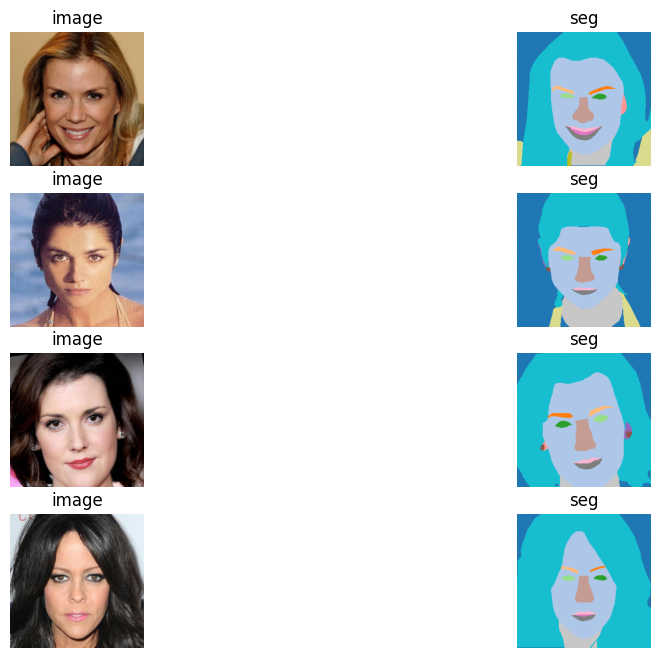

1 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


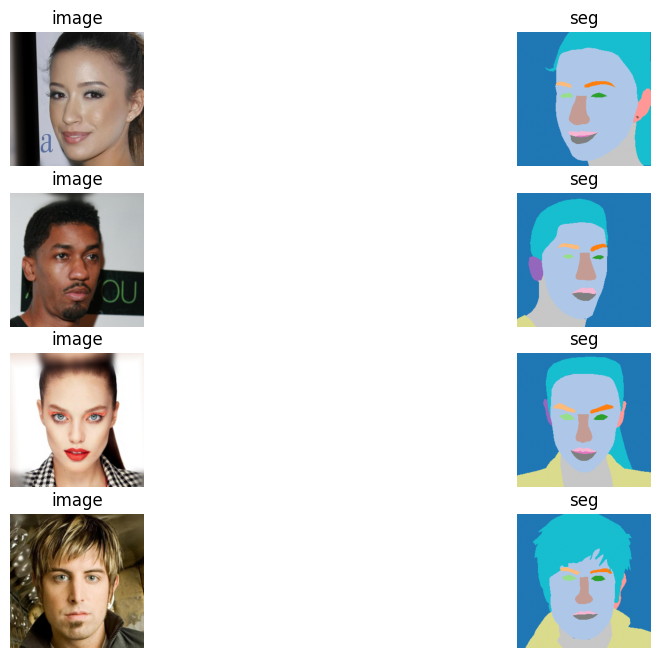

2 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


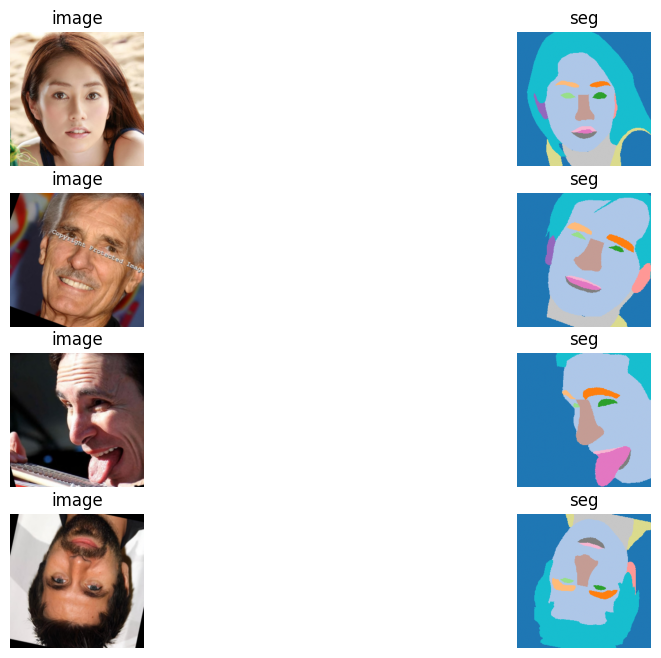

In [ ]:
import matplotlib.pyplot as plt

# let's create a DataLoader to easily iterate over this dataset
bs = 4
dataloader = torch.utils.data.DataLoader(dataset1, batch_size=bs, shuffle=True, num_workers=0)


for i_batch, sample_batched in enumerate(dataloader):
    imgs = sample_batched[0]
    segs = sample_batched[1]
    print(i_batch, imgs.size(), segs.size())


    rows, cols = bs, 2
    figure = plt.figure(figsize=(bs*3, bs*2))
    for i in range(0, bs):
        figure.add_subplot(rows, cols, 2*i+1)
        plt.title('image')
        plt.axis("off")
        plt.imshow(imgs[i].permute(1, 2, 0).numpy())


        figure.add_subplot(rows, cols, 2*i+2)
        plt.title('seg')
        plt.axis("off")
        plt.imshow(segs[i].numpy(), cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.show()
    # display the first 3 batches
    if i_batch == 2:
      break

Let us see also the v2 transformations

0 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


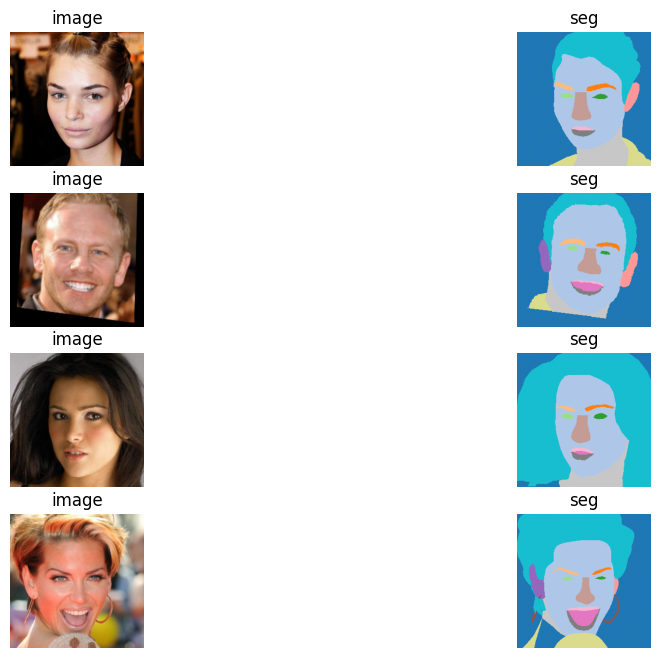

1 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


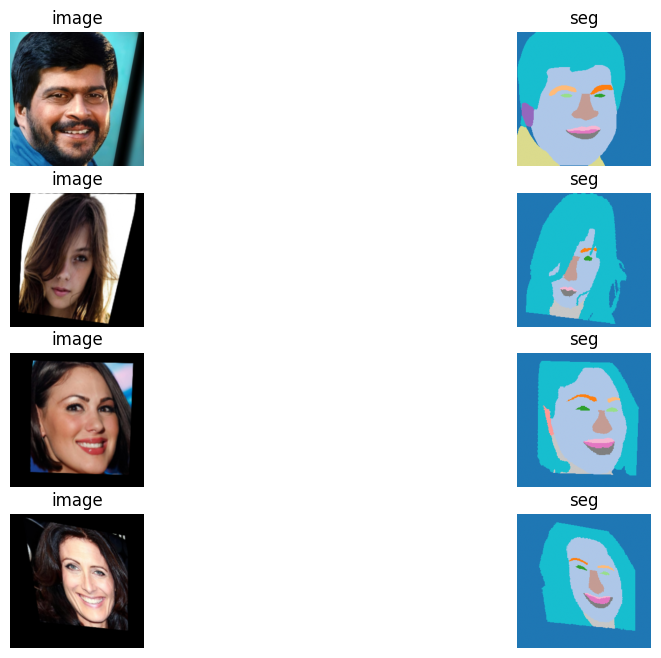

2 torch.Size([4, 3, 256, 256]) torch.Size([4, 256, 256])


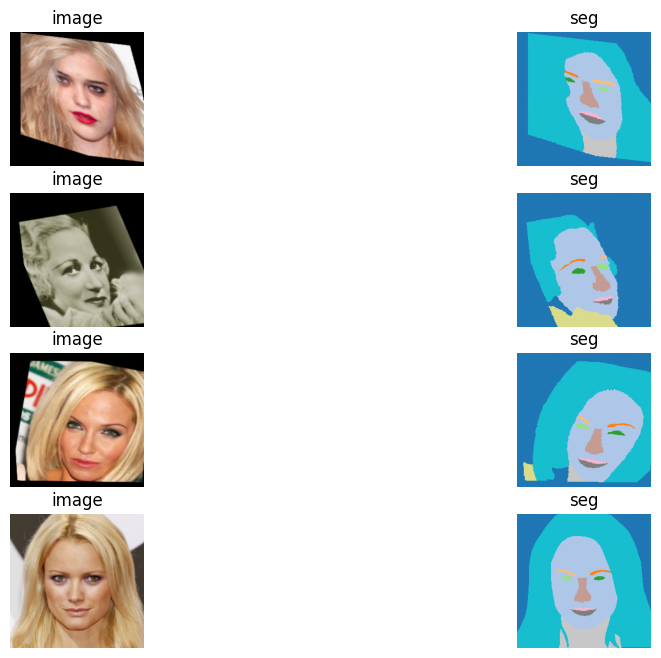

In [ ]:
import matplotlib.pyplot as plt

# let's create a DataLoader to easily iterate over this dataset
bs = 4
dataloader = torch.utils.data.DataLoader(dataset2, batch_size=bs, shuffle=True, num_workers=0)


for i_batch, sample_batched in enumerate(dataloader):
    imgs = sample_batched[0]
    segs = sample_batched[1]
    print(i_batch, imgs.size(), segs.size())


    rows, cols = bs, 2
    figure = plt.figure(figsize=(bs*3, bs*2))
    for i in range(0, bs):
        figure.add_subplot(rows, cols, 2*i+1)
        plt.title('image')
        plt.axis("off")
        plt.imshow(imgs[i].permute(1, 2, 0).numpy())


        figure.add_subplot(rows, cols, 2*i+2)
        plt.title('seg')
        plt.axis("off")
        plt.imshow(segs[i].numpy(), cmap="tab20", vmin=0, vmax=NUM_CLASSES - 1)
    plt.show()
    # display the first 3 batches
    if i_batch == 2:
      break

# 2. Implementing the building blocks of the UNet

### Encoder

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, nr_channels_list):
        super(Encoder, self).__init__()

        # UsingModuleList so PyTorch properly registers all layers
        self.blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Build each block dynamically from nr_channels_list
        # Each block: Conv -> ReLU -> Conv
        # nr_channels_list pairs: (in, mid, out) per block
        # e.g. block i uses channels[2*i] -> channels[2*i+1] -> channels[2*i+2]
        num_blocks = (len(nr_channels_list) - 1) // 2
        for i in range(num_blocks):
            in_ch  = nr_channels_list[2 * i]
            mid_ch = nr_channels_list[2 * i + 1]
            out_ch = nr_channels_list[2 * i + 2]
            block = nn.Sequential(
                nn.Conv2d(in_ch,  mid_ch, kernel_size=3),
                nn.ReLU(inplace=True),
                nn.Conv2d(mid_ch, out_ch, kernel_size=3),
            )
            self.blocks.append(block)

    def forward(self, x):
        block_outputs = []

        for i, block in enumerate(self.blocks):
            x = block(x)               # Conv -> ReLU -> Conv
            block_outputs.append(x)    # Save output BEFORE pooling (used as skip connections)
            if i < len(self.blocks) - 1:
                x = self.pool(x)       # Pool between blocks, not after the last one

        return block_outputs           # List of skip-connection feature maps

# Channel list: [in, mid1, out1,  mid2, out2,  mid3, out3,  mid4, out4]
# Classic U-Net encoder with 4 blocks, starting from 1-channel (grayscale) input
nr_channels_list = [1, 64, 64, 128, 128, 256, 256, 512, 512]

net = Encoder(nr_channels_list)
print(net)

Encoder(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
    )
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


### Decoder

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def upsample_block(x, filters, size, stride=2):
    """
    x       - the input of the upsample block
    filters - the number of filters to be applied
    size    - the size of the filters
    """
    in_channels = x.shape[1]  #channels dimension (B, C, H, W)

    # Transposed convolution (no padding → P=0, so Wo = (Wi-1)*S + F)
    conv_transpose = nn.ConvTranspose2d(
        in_channels=in_channels,
        out_channels=filters,
        kernel_size=size,
        stride=stride,
        padding=0
    )

    # Batch Normalization
    bn = nn.BatchNorm2d(filters)

    # Forward pass: ConvTranspose -> BN -> ReLU
    x = conv_transpose(x)
    x = bn(x)
    x = F.relu(x)

    return x

in_layer = torch.rand((32, 32, 128, 128))

filter_sz   = 4
num_filters = 16

for stride in [2, 4, 8]:
    x = upsample_block(in_layer, num_filters, filter_sz, stride)
    print(f'in shape: {in_layer.shape}  |  filter={filter_sz}, stride={stride}  ->  out shape: {x.shape}')

in shape: torch.Size([32, 32, 128, 128])  |  filter=4, stride=2  ->  out shape: torch.Size([32, 16, 258, 258])
in shape: torch.Size([32, 32, 128, 128])  |  filter=4, stride=4  ->  out shape: torch.Size([32, 16, 512, 512])
in shape: torch.Size([32, 32, 128, 128])  |  filter=4, stride=8  ->  out shape: torch.Size([32, 16, 1020, 1020])


In [ ]:
import torchvision.transforms.functional as TF
class Decoder(nn.Module):
    def __init__(self, dec_channels, skip_channels):
        """
        dec_channels  : output channels at each decoder stage, e.g. [512, 256, 128, 64]
        skip_channels : channels of encoder skips (deep → shallow), e.g. [512, 256, 128, 64]

        For each block i:
          - upsample:  dec_channels[i]  → dec_channels[i+1]
          - concat:    dec_channels[i+1] + skip_channels[i]   (these can differ!)
          - conv:      dec_channels[i+1] + skip_channels[i]   → dec_channels[i+1]
        """
        super(Decoder, self).__init__()

        self.upsample_blocks = nn.ModuleList()
        self.conv_blocks     = nn.ModuleList()

        num_blocks = len(dec_channels) - 1

        for i in range(num_blocks):
            in_ch   = dec_channels[i]
            out_ch  = dec_channels[i + 1]
            skip_ch = skip_channels[i]          # actual encoder skip channels

            self.upsample_blocks.append(nn.Sequential(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ))

            # concat_ch = out_ch + skip_ch
            self.conv_blocks.append(nn.Sequential(
                nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch,           out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
            ))

    def forward(self, x, encoder_activations):
        for i, (up, conv) in enumerate(zip(self.upsample_blocks, self.conv_blocks)):
            x    = up(x)
            skip = encoder_activations[-(i + 1)]
            _, _, h, w = x.shape
            skip = TF.center_crop(skip, [h, w])
            x    = torch.cat([x, skip], dim=1)
            x    = conv(x)
        return x



enc_channels  = [1, 64, 64, 128, 128, 256, 256, 512, 512]

# encoder block output channels, deep → shallow
skip_channels = [512, 256, 128, 64]
dec_channels  = [512, 256, 128, 64]

encoder = Encoder(enc_channels)
decoder = Decoder(dec_channels, skip_channels)

x_in             = torch.rand(1, 1, 572, 572)
skip_connections = encoder(x_in)                    # [64ch, 128ch, 256ch, 512ch]
bottleneck       = skip_connections[-1]             # 512 channels, 64×64
bottleneck_pooled = nn.MaxPool2d(2, 2)(bottleneck)

out = decoder(bottleneck_pooled, skip_connections)
print("Decoder output shape:", out.shape)

print(decoder)

Decoder output shape: torch.Size([1, 64, 228, 228])
Decoder(
  (upsample_blocks): ModuleList(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (conv_blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      (3): ReLU(inplace=True)
    )

# U-Net implementation
Putting together the building blocks

In [ ]:
class UNet1(nn.Module):
    def __init__(self, enc_channels, dec_channels, skip_channels, num_classes):
        """
        enc_channels  : channel list for the encoder, e.g. [1, 64, 64, 128, 128, 256, 256, 512, 512]
        dec_channels  : channel list for the decoder, e.g. [512, 256, 128, 64]
        skip_channels : encoder skip channels deep→shallow, e.g. [512, 256, 128, 64]
        num_classes   : number of segmentation classes (output channels)
        """
        super(UNet1, self).__init__()

        self.encoder   = Encoder(enc_channels)
        self.decoder   = Decoder(dec_channels, skip_channels)
        self.pool      = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1×1 conv: maps decoder output channels → num_classes
        self.seg_head  = nn.Conv2d(
            in_channels  = dec_channels[-1],
            out_channels = num_classes,
            kernel_size  = 1
        )

    def forward(self, x):
        target_size = x.shape[-2:]          # (H, W) of the original input — used for final resize

        # enoder(down-sampling path)
        skip_connections = self.encoder(x)  # list [block1_out, ..., blockN_out]
        bottleneck       = skip_connections[-1]

        # Pool the deepest encoder output before handing it to the decoder
        bottleneck_pooled = self.pool(bottleneck)

        #Decoder (up-sampling path)
        x = self.decoder(bottleneck_pooled, skip_connections)

        #Segmentation head: 1×1 conv → (B, num_classes, H', W')
        x = self.seg_head(x)

        #Resize to match ground-truth spatial dimensions
        # bilinear interpolation; align_corners=False is the standard choice
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

        return x   # shape: (B, num_classes, H, W)



enc_channels  = [1, 64, 64, 128, 128, 256, 256, 512, 512]
dec_channels  = [512, 256, 128, 64]
skip_channels = [512, 256, 128, 64]   # deep → shallow
num_classes   = 19

model  = UNet1(enc_channels, dec_channels, skip_channels, num_classes)
x_in   = torch.rand(1, 1, 572, 572)
out    = model(x_in)

print("Input  shape :", x_in.shape)
print("Output shape :", out.shape)

print(model)



Input  shape : torch.Size([1, 1, 572, 572])
Output shape : torch.Size([1, 19, 572, 572])
UNet1(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      )
      (3): Sequential(
        (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fals

# Preparing the data to train later - split the training and val data into dataloaders


We can use some of the previous transformations when we load the images

In [ ]:
import torch
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from torch.utils.data import DataLoader
import random


def train_transforms(image: Image.Image, mask: Image.Image):
    #Resize
    image = TF.resize(image, (256, 256))
    mask  = TF.resize(mask,  (256, 256), interpolation=T.InterpolationMode.NEAREST)

    #Random horizontal flip (same decision for both)
    if random.random() > 0.5:
        image = TF.hflip(image)
        mask  = TF.hflip(mask)

    #Random crop (same crop for both)
    i, j, h, w = T.RandomCrop.get_params(image, output_size=(224, 224))
    image = TF.crop(image, i, j, h, w)
    mask  = TF.crop(mask,  i, j, h, w)

    #To tensor + normalize
    image = TF.to_tensor(image)                          # (3, H, W) float32 in [0,1]
    image = TF.normalize(image,
                         mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))

    mask = torch.from_numpy(np.array(mask)).long()       # (H, W) int64

    return image, mask


def val_transforms(image: Image.Image, mask: Image.Image):
    #No augmentation -just resize and normalize
    image = TF.resize(image, (256, 256))
    mask  = TF.resize(mask,  (256, 256), interpolation=T.InterpolationMode.NEAREST)

    image = TF.to_tensor(image)
    image = TF.normalize(image,
                         mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))

    mask = torch.from_numpy(np.array(mask)).long()

    return image, mask




Let us reload the 3 subsets, but use in the training subsets the tranformations defined above. For computational reasons, we used only 1/4 of the training subset (7000 images, not 28000).

In [ ]:
dataset_train_full = CelebAMaskHQDataset(
    base_folder="celeba_mask_hq",
    zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",
    transforms=train_transforms,
    split="train",
    extract=True,
)

# Create a subset for faster training (1/4th of the original dataset)
subset_size = len(dataset_train_full) // 4
indices = torch.randperm(len(dataset_train_full)).tolist()[:subset_size]
dataset_train = torch.utils.data.Subset(dataset_train_full, indices)


dataset_val = CelebAMaskHQDataset(
    base_folder="celeba_mask_hq",
    zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",
    transforms=val_transforms,
    split="val",
    extract=True,
)

dataset_test = CelebAMaskHQDataset(
    base_folder="celeba_mask_hq",
    zip_path="/content/drive/MyDrive/CelebAMask-HQ.zip",
    transforms=val_transforms,   # same as val — no augmentation
    split="test",
    extract=True,
)


#DataLoaders

train_loader = DataLoader(
    dataset_train,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,       # avoids a batch-norm edge case on the last small batch
)

val_loader = DataLoader(
    dataset_val,
    batch_size=32,
    shuffle=False,        # never shuffle val/test
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    dataset_test,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

Extracting '/content/drive/MyDrive/CelebAMask-HQ.zip' → 'celeba_mask_hq' …
  402800/402800 files extracted
Extraction complete.
Dataset already extracted at 'celeba_mask_hq/CelebAMask-HQ'. Skipping extraction.
Dataset already extracted at 'celeba_mask_hq/CelebAMask-HQ'. Skipping extraction.


In [ ]:
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of batches in train_loader: 218
Number of batches in test_loader: 32


## Now that the data is completely prepared, let us get to the next part in the requirement file

# 3. Loss functions for semantic segmentation

Defining Dice and the combined loss, with weighted Dice and Pixel CE. I used a weight also for Dice, for us to be easier to work with only this cobined loss, regarding all the trainings we shall perform.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DiceLoss(nn.Module):
    """
    Multiclass Dice loss averaged over all classes.

    Args:
        smooth (float): Laplace smoothing term to avoid division by zero.
        ignore_index (int): Class index to exclude (e.g. background).
                            Set to -1 to include all classes.
    """
    def __init__(self, smooth: float = 1.0, ignore_index: int = -1):
        super().__init__()
        self.smooth = smooth
        self.ignore_index = ignore_index

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits  : (B, C, H, W) — raw model outputs (before softmax)
            targets : (B, H, W)    — integer class labels in [0, C-1]
        Returns:
            Scalar Dice loss.
        """
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)                      # (B, C, H, W)

        # One-hot encode targets -> (B, C, H, W)
        targets_one_hot = F.one_hot(targets, num_classes)     # (B, H, W, C)
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2) # (B, C, H, W)
        targets_one_hot = targets_one_hot.float()

        # Determine which classes to score
        classes = list(range(num_classes))
        if self.ignore_index in classes:
            classes.remove(self.ignore_index)

        dice_per_class = []
        for c in classes:
            p = probs[:, c]           # (B, H, W)
            g = targets_one_hot[:, c] # (B, H, W)

            intersection = (p * g).sum(dim=(1, 2))            # (B,)
            union        = p.sum(dim=(1, 2)) + g.sum(dim=(1, 2))  # (B,)

            dice_c = (2.0 * intersection + self.smooth) / (union + self.smooth)
            dice_per_class.append(dice_c.mean())              # scalar

        mean_dice = torch.stack(dice_per_class).mean()
        return 1.0 - mean_dice


class SegmentationLoss(nn.Module):
    """
    Combined Cross-Entropy + Dice loss:

        L = a* L_CE + b* L_Dice

    Args:
        a (float):  Weight a on the Cross Entropy term (default 1.0).
        b (float):  Weight b on the Dice term (default 1.0).
        ce_ignore_index (int): Passed to CrossEntropyLoss (pixels to ignore).
        dice_ignore_index (int): Class excluded from Dice (e.g. background = 0).
        dice_smooth (float):  Laplace smoothing for Dice.
        class_weights (Tensor, optional): Per-class weights for CrossEntropyLoss,
                                          shape (C,). Useful for class imbalance.
    """
    def __init__(
        self,
        a: float = 1.0,
        b: float = 1.0,
        ce_ignore_index: int = -100,
        dice_ignore_index: int = -1,
        dice_smooth: float = 1.0,
        class_weights: torch.Tensor = None,
    ):
        super().__init__()
        self.a = a
        self.b = b

        self.ce_loss = nn.CrossEntropyLoss(
            weight=class_weights,
            ignore_index=ce_ignore_index,
        )
        self.dice_loss = DiceLoss(
            smooth=dice_smooth,
            ignore_index=dice_ignore_index,
        )

    def forward(
        self, logits: torch.Tensor, targets: torch.Tensor
    ) -> tuple[torch.Tensor, dict]:
        """
        Args:
            logits  : (B, C, H, W) — raw model outputs
            targets : (B, H, W)    — integer ground-truth labels
        Returns:
            total_loss : scalar tensor (backpropagatable)
            components : dict with individual loss values for logging
        """
        l_ce   = self.ce_loss(logits, targets)
        l_dice = self.dice_loss(logits, targets)
        total  = self.a * l_ce + self.b * l_dice

        return total, {
            "loss":      total.item(),
            "loss_ce":   l_ce.item(),
            "loss_dice": l_dice.item(),
        }

# 4. Logging and evaluation metrics

In [ ]:
import torch


class SegmentationMetrics:
    def __init__(self, num_classes: int, ignore_index: int = -1, device="cpu"):
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.device       = device
        self.cm = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)

    def reset(self):
        self.cm.zero_()

    @torch.no_grad()
    def update(self, logits: torch.Tensor, targets: torch.Tensor):
        preds   = logits.argmax(dim=1).view(-1)
        targets = targets.view(-1)
        if self.ignore_index >= 0:
            valid   = targets != self.ignore_index
            preds   = preds[valid]
            targets = targets[valid]
        indices = self.num_classes * targets + preds
        self.cm += torch.bincount(
            indices, minlength=self.num_classes ** 2
        ).view(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm      = self.cm.float()
        tp      = cm.diag()
        gt_sum  = cm.sum(dim=1)
        pred_sum= cm.sum(dim=0)
        present = gt_sum > 0

        # Mean Pixel Accuracy
        acc          = torch.zeros_like(tp)
        acc[present] = tp[present] / gt_sum[present]
        mpa          = acc[present].mean().item()

        # IoU per class + mIoU
        union        = gt_sum + pred_sum - tp
        iou          = torch.zeros_like(tp)
        valid        = union > 0
        iou[valid]   = tp[valid] / union[valid]
        miou         = iou[present].mean().item()

        # Frequency-Weighted IoU
        total = gt_sum[present].sum()
        fwiou = ((gt_sum[present] / total) * iou[present]).sum().item()

        return {
            "mean_pixel_accuracy": mpa,
            "miou":                miou,
            "fwiou":               fwiou,
            "iou_per_class":       iou.cpu().tolist(),
        }

#5. Training the model

### 5.1. Learned Upsampling with Different Loss Configurations

In [ ]:
print(model)

UNet1(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      )
      (3): Sequential(
        (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Decoder(
    (upsample_blocks): ModuleList(
      (0): Sequential(
  

### Performing the wandb sweep

Wandb color maps helper functions and definitions

In [ ]:
import wandb
import torch
import numpy as np
from torch.optim import lr_scheduler


#Colour palette for the 19 CelebAMask-HQ classes (index = class ID)
PALETTE = torch.tensor([
    [0,   0,   0  ],  # 0  background
    [255, 0,   0  ],  # 1  skin
    [255, 85,  0  ],  # 2  l_brow
    [255, 170, 0  ],  # 3  r_brow
    [255, 255, 0  ],  # 4  l_eye
    [170, 255, 0  ],  # 5  r_eye
    [85,  255, 0  ],  # 6  eye_g
    [0,   255, 0  ],  # 7  l_ear
    [0,   255, 85 ],  # 8  r_ear
    [0,   255, 170],  # 9  ear_r
    [0,   255, 255],  # 10 nose
    [0,   170, 255],  # 11 mouth
    [0,   85,  255],  # 12 u_lip
    [0,   0,   255],  # 13 l_lip
    [85,  0,   255],  # 14 neck
    [170, 0,   255],  # 15 neck_l
    [255, 0,   255],  # 16 cloth
    [255, 0,   170],  # 17 hair
    [255, 0,   85 ],  # 18 hat
], dtype=torch.uint8)  # (19, 3)


def labels_to_rgb(mask: torch.Tensor) -> np.ndarray:
    """
    Convert an integer label map (H, W) → RGB numpy array (H, W, 3).
    Used for WandB mask overlay visualisations.
    """
    rgb = PALETTE[mask.cpu()]          # (H, W, 3)
    return rgb.numpy()


def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """
    Undo ImageNet normalisation and return a uint8 HWC numpy array.
    tensor : (3, H, W) float32
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1)
    return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)


def make_wandb_images(images, masks_gt, masks_pred, n: int = 4):
    """
    Build a list of wandb.Image objects with ground-truth and predicted
    mask overlays for the first *n* images in the batch.
    """
    wandb_imgs = []
    for i in range(min(n, images.shape[0])):
        img_np      = denormalize(images[i])          # (H, W, 3) uint8
        gt_rgb      = labels_to_rgb(masks_gt[i])      # (H, W, 3)
        pred_rgb    = labels_to_rgb(masks_pred[i])    # (H, W, 3)

        # Overlay: blend image 60% + mask colour 40%
        gt_overlay   = (0.6 * img_np + 0.4 * gt_rgb).astype(np.uint8)
        pred_overlay = (0.6 * img_np + 0.4 * pred_rgb).astype(np.uint8)

        # Stack side-by-side: image | GT | prediction
        row = np.concatenate([img_np, gt_overlay, pred_overlay], axis=1)
        wandb_imgs.append(wandb.Image(row, caption="Image | GT | Pred"))

    return wandb_imgs

Single epoch run

In [ ]:
def run_epoch(model, loader, criterion, optimizer, metrics, device,
              train: bool, log_images: bool = False):
    model.train() if train else model.eval()
    metrics.reset()
    total_loss = total_ce = total_dice = 0.0
    sample_imgs = None                    # will hold one batch for visualisation

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_idx, (images, masks) in enumerate(loader):
            images = images.to(device)
            masks  = masks.to(device)

            logits          = model(images)
            loss, log       = criterion(logits, masks)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += log["loss"]
            total_ce   += log["loss_ce"]
            total_dice += log["loss_dice"]
            metrics.update(logits, masks)

            # Save the first batch for WandB visualisation
            if log_images and sample_imgs is None:
                sample_imgs = (
                    images.detach().cpu(),
                    masks.detach().cpu(),
                    logits.argmax(dim=1).detach().cpu(),
                )

    n       = len(loader)
    results = metrics.compute()
    results.update({
        "loss":      total_loss / n,
        "loss_ce":   total_ce   / n,
        "loss_dice": total_dice / n,
    })
    if log_images and sample_imgs is not None:
        results["_sample_imgs"] = sample_imgs   # passed through for logging

    return results

Wandb sweep run

In [ ]:
def sweep_run():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    wandb.init()
    config = wandb.config

    model = UNet1(
        enc_channels=config.enc_channels,
        dec_channels=config.dec_channels,
        skip_channels=config.skip_channels,
        num_classes=19,
    ).to(device)

    # Instantiate SegmentationLoss using parameters from config
    a, b = config.loss_function
    criterion = SegmentationLoss(a=a, b=b, dice_ignore_index=0).to(device)

    metrics   = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5,
    patience=3, min_lr=1e-5
)

    for epoch in range(1, config.num_epochs + 1):
        log_imgs = (epoch == 1 or epoch % 5 == 0)

        train_r = run_epoch(
            model, train_loader, criterion, optimizer,
            metrics, device, train=True, log_images=log_imgs
        )
        val_r = run_epoch(
            model, val_loader, criterion, None,
            metrics, device, train=False, log_images=log_imgs
        )

        scheduler.step(val_r["miou"])

        # ── WandB logging ──────────────────────────────
        log_dict = {
            "epoch": epoch,
            "lr":    optimizer.param_groups[0]["lr"],

            # Losses
            "train/loss":      train_r["loss"],
            "train/loss_ce":   train_r["loss_ce"],
            "train/loss_dice": train_r["loss_dice"],
            "val/loss":        val_r["loss"],
            "val/loss_ce":     val_r["loss_ce"],
            "val/loss_dice":   val_r["loss_dice"],

            # Scalar metrics
            "train/mpa":   train_r["mean_pixel_accuracy"],
            "train/miou":  train_r["miou"],
            "train/fwiou": train_r["fwiou"],
            "val/mpa":     val_r["mean_pixel_accuracy"],
            "val/miou":    val_r["miou"],
            "val/fwiou":   val_r["fwiou"],
        }

        # Per-class IoU as a WandB bar chart
        PART_NAMES = ["bg","skin","l_brow","r_brow","l_eye","r_eye","eye_g",
                      "l_ear","r_ear","ear_r","nose","mouth","u_lip","l_lip",
                      "neck","neck_l","cloth","hair","hat"]
        log_dict["val/iou_per_class"] = wandb.plot.bar(
            wandb.Table(
                columns=["class", "IoU"],
                data=[[name, iou]
                      for name, iou in zip(PART_NAMES, val_r["iou_per_class"])]
            ),
            "class", "IoU", title="Val IoU per class"
        )

        # Mask overlay visualisations
        if log_imgs:
            for split, r in [("train", train_r), ("val", val_r)]:
                if "_sample_imgs" in r:
                    imgs, gt, pred = r["_sample_imgs"]
                    log_dict[f"{split}/predictions"] = make_wandb_images(
                        imgs, gt, pred, n=4
                    )

        wandb.log(log_dict)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {train_r['loss']:.4f}/{val_r['loss']:.4f} | "
            f"mIoU {train_r['miou']:.4f}/{val_r['miou']:.4f} | "
            f"MPA {train_r['mean_pixel_accuracy']:.4f}/{val_r['mean_pixel_accuracy']:.4f} | "
            f"FWIoU {train_r['fwiou']:.4f}/{val_r['fwiou']:.4f}"
        )

    wandb.finish()


Wandb grid search configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

grid_sweep_cfg = {
    "method": "grid",
    "metric": {"name": "val/miou", "goal": "maximize"},
    "parameters": {
        "num_epochs":    {"value": 30},
        "lr":            {"value": 0.001},
        "enc_channels":  {"value": [3, 64, 64, 128, 128, 256, 256, 512, 512]},
        "dec_channels":  {"value": [512, 256, 128, 64]},
        "skip_channels": {"value": [512, 256, 128, 64]},
        "loss_function": {
            "values": [
                (1.0, 0), # only dice
                (0.0, 1.0), # only Pixel CE
                (1.0, 1.0),
                (1.0, 2.0),    # different weights for each
                (1.0, 3.0)
            ]
        },
    },
}

sweep_id = wandb.sweep(grid_sweep_cfg, project="U_Net_Learned_Upsampling_Different_Loss_Functions4")
wandb.agent(sweep_id, function=sweep_run)

Due to computational reasons, usually the entire grid search cannot be performed on a single Google Colab account (only if you have premium I think you can actually do this), so what I did was to try these configurations ((1.0, 0),
                (0.0, 1.0),
                (1.0, 1.0),
                (1.0, 2.0),
                (1.0, 3.0)) each on a different Google account. I kept this grid search structure for simplicity and for me to be easier to track what values I used and what values I did not try when training the UNet.

Anyways, you can see the training and validation curves, together with their losses, here:
- part 1 : https://api.wandb.ai/links/dragostrandafir443-babes/huqgkz83
- part 2: https://api.wandb.ai/links/dragostrandafir443-babes/9ahlbpnd
- part 3: https://api.wandb.ai/links/dragostrandafir443-babes/zkw65bht

!!! When comparing different curves, I took into consideration both training and validation metrics. When comparing models between them, I paid attentions also to the nr of epochs, because in some cases, some models were trained for a number of epochs < 30 (again due to Google Colab interruptions :)) ), because it is not fair to compare the 30th epoch of model1 with the 24th epoch of model2, for example.

A first thing to mention is that val and train curves are somehow syncronized, i.e. they reflect a similar behaviour, so we do not have overfitting. Of course, this can be explained by the simplicity of the custom-built UNet and the big dataset we are working with, which has 19 classes (complex segmentation problem). Also, the nr of epochs is ~30, and the metrics show potential to improve even after the 30th epoch.

From the start, the most obvious is (1,0), which starts overfitting even around the ~20th epoch (notice the val/fwiou and training metrics, without the losses), even if the losses both in val and train subsets are smaller. This is probably because cross-entropy alone may bias the model toward predicting the dominant class, without considering smaller objects through Dice.

Also, (0,1) (Dice alone) does not work, because we do not have the help from Pixel CE, to guide us to a general mask through bigger objects ,so it is impossible to fit the predicted mask on the ground-truth mask. Basically, we do not have a general setting to begin with. That is why the curves become linear very fast and the CE loss starts to grow in train (unwanted behaviour) or is very unstable and fluctuant in validation.

The remaining configurations are (1,1), (1,2) and (1,3), all of them representing a configuration of the recommended version in the requirement PDF. All of the curves behave well, with the validation ones being more unstable than the training ones (normal behaviour). The difference between them is not extremely big, again maybe because the model is small and nr of epochs is not too big. Regaring the visualizations (predicted segmentation map overlapped with the GT map), these 3 models manage to partially detect the nose, hair, neck and sometimes, there are classes that cover a bigger part of the image; but fail to accurately detect smaller classes, such as eyebrows or eyes. This could improve if the nr of epoch would increase and we would use the whole dataset.

We can see that the model with configuration (1.0, 3.0) provides the best final results - this can be because the model learns to segment the casses that cover the most part of the image, but the small classes are also taken into account. Us having a total of 19 classes, with most of them covering about 2-3% of the image, it is normal that a crucial thing for the model is to learn those small classes, that is why Dice having such big weight (3) gives us an advantage here.



### 5.4. Unlearned Upsampling, using the configuration (1,3) from before

Let us first create the 2 unlearned decoders

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF


#1. Nearest-Neighbour Decoder
class DecoderNearest(nn.Module):
    def __init__(self, dec_channels, skip_channels):
        """
        Nearest-neighbour upsampling (no learned weights in the upsample step).

        Upsampling path per block:
          Upsample(×2, nearest) → Conv2d(in_ch → out_ch, 1×1)  [channel projection]
          → BN → ReLU
        Then the same concat + double-conv as the original decoder.
        """
        super().__init__()
        self.upsample_blocks = nn.ModuleList()
        self.conv_blocks     = nn.ModuleList()

        for i in range(len(dec_channels) - 1):
            in_ch   = dec_channels[i]
            out_ch  = dec_channels[i + 1]
            skip_ch = skip_channels[i]

            #upsample block
            # Upsample doubles H,W; 1×1 conv projects channels in_ch -> out_ch
            self.upsample_blocks.append(nn.Sequential(
                nn.Upsample(scale_factor=2, mode='nearest'),
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ))

            #refinement block (identical to original)
            self.conv_blocks.append(nn.Sequential(
                nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch,           out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
            ))

    def forward(self, x, encoder_activations):
        for i, (up, conv) in enumerate(zip(self.upsample_blocks, self.conv_blocks)):
            x    = up(x)
            skip = encoder_activations[-(i + 1)]
            _, _, h, w = x.shape
            skip = TF.center_crop(skip, [h, w])   # align skip to upsampled map
            x    = torch.cat([x, skip], dim=1)
            x    = conv(x)
        return x


# 2. Bilinear Interpolation Decoder
class DecoderBilinear(nn.Module):
    def __init__(self, dec_channels, skip_channels):
        """
        Bilinear upsampling (no learned weights in the upsample step).

        Upsampling path per block:
          Upsample(×2, bilinear, align_corners=False) → Conv2d(in_ch → out_ch, 1×1)
          → BN → ReLU
        Then the same concat + double-conv as the original decoder.
        """
        super().__init__()
        self.upsample_blocks = nn.ModuleList()
        self.conv_blocks     = nn.ModuleList()

        for i in range(len(dec_channels) - 1):
            in_ch   = dec_channels[i]
            out_ch  = dec_channels[i + 1]
            skip_ch = skip_channels[i]

            # upsample block
            self.upsample_blocks.append(nn.Sequential(
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ))

            # refinement block (identical to original)
            self.conv_blocks.append(nn.Sequential(
                nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch,           out_ch, kernel_size=3),
                nn.ReLU(inplace=True),
            ))

    def forward(self, x, encoder_activations):
        for i, (up, conv) in enumerate(zip(self.upsample_blocks, self.conv_blocks)):
            x    = up(x)
            skip = encoder_activations[-(i + 1)]
            _, _, h, w = x.shape
            skip = TF.center_crop(skip, [h, w])
            x    = torch.cat([x, skip], dim=1)
            x    = conv(x)
        return x


skip_channels = [512, 256, 128, 64]
dec_channels  = [512, 256, 128, 64]

decoder_orig     = Decoder(dec_channels, skip_channels)
decoder_nearest  = DecoderNearest(dec_channels, skip_channels)
decoder_bilinear = DecoderBilinear(dec_channels, skip_channels)

x_in             = torch.rand(1, 1, 572, 572)
skip_connections = encoder(x_in)
bottleneck       = skip_connections[-1]
bottleneck_pooled = nn.MaxPool2d(2, 2)(bottleneck)

for name, dec in [("Original (ConvTranspose)", decoder_orig),
                  ("Nearest-neighbour",         decoder_nearest),
                  ("Bilinear",                  decoder_bilinear)]:
    out = dec(bottleneck_pooled, skip_connections)
    print(f"{name:30s}  →  {out.shape}")

Original (ConvTranspose)        →  torch.Size([1, 64, 228, 228])
Nearest-neighbour               →  torch.Size([1, 64, 228, 228])
Bilinear                        →  torch.Size([1, 64, 228, 228])


And the new UNets that use them

In [ ]:
class UNetNearest(nn.Module):
    def __init__(self, enc_channels, dec_channels, skip_channels, num_classes):
        """
        enc_channels  : channel list for the encoder, e.g. [1, 64, 64, 128, 128, 256, 256, 512, 512]
        dec_channels  : channel list for the decoder, e.g. [512, 256, 128, 64]
        skip_channels : encoder skip channels deep→shallow, e.g. [512, 256, 128, 64]
        num_classes   : number of segmentation classes (output channels)
        """
        super(UNetNearest, self).__init__()

        self.encoder   = Encoder(enc_channels)
        self.decoder   = DecoderNearest(dec_channels, skip_channels)
        self.pool      = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1×1 conv: maps decoder output channels → num_classes
        self.seg_head  = nn.Conv2d(
            in_channels  = dec_channels[-1],
            out_channels = num_classes,
            kernel_size  = 1
        )

    def forward(self, x):
        target_size = x.shape[-2:]          # (H, W) of the original input — used for final resize

        # enoder(down-sampling path)
        skip_connections = self.encoder(x)  # list [block1_out, ..., blockN_out]
        bottleneck       = skip_connections[-1]

        # Pool the deepest encoder output before handing it to the decoder
        bottleneck_pooled = self.pool(bottleneck)

        #Decoder (up-sampling path)
        x = self.decoder(bottleneck_pooled, skip_connections)

        #Segmentation head: 1×1 conv → (B, num_classes, H', W')
        x = self.seg_head(x)

        #Resize to match ground-truth spatial dimensions
        # bilinear interpolation; align_corners=False is the standard choice
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

        return x   # shape: (B, num_classes, H, W)



enc_channels  = [1, 64, 64, 128, 128, 256, 256, 512, 512]
dec_channels  = [512, 256, 128, 64]
skip_channels = [512, 256, 128, 64]
num_classes   = 19

model_nearest  = UNetNearest(enc_channels, dec_channels, skip_channels, num_classes)
x_in   = torch.rand(1, 1, 572, 572)
out    = model_nearest(x_in)

print("Input  shape :", x_in.shape)
print("Output shape :", out.shape)

print(model_nearest)



Input  shape : torch.Size([1, 1, 572, 572])
Output shape : torch.Size([1, 19, 572, 572])
UNetNearest(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      )
      (3): Sequential(
        (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mod

In [ ]:
class UNetBilinear(nn.Module):
    def __init__(self, enc_channels, dec_channels, skip_channels, num_classes):
        """
        enc_channels  : channel list for the encoder, e.g. [1, 64, 64, 128, 128, 256, 256, 512, 512]
        dec_channels  : channel list for the decoder, e.g. [512, 256, 128, 64]
        skip_channels : encoder skip channels deep→shallow, e.g. [512, 256, 128, 64]
        num_classes   : number of segmentation classes (output channels)
        """
        super(UNetBilinear, self).__init__()

        self.encoder   = Encoder(enc_channels)
        self.decoder   = DecoderBilinear(dec_channels, skip_channels)
        self.pool      = nn.MaxPool2d(kernel_size=2, stride=2)

        # 1×1 conv: maps decoder output channels → num_classes
        self.seg_head  = nn.Conv2d(
            in_channels  = dec_channels[-1],
            out_channels = num_classes,
            kernel_size  = 1
        )

    def forward(self, x):
        target_size = x.shape[-2:]          # (H, W) of the original input — used for final resize

        # enoder(down-sampling path)
        skip_connections = self.encoder(x)  # list [block1_out, ..., blockN_out]
        bottleneck       = skip_connections[-1]

        # Pool the deepest encoder output before handing it to the decoder
        bottleneck_pooled = self.pool(bottleneck)

        #Decoder (up-sampling path)
        x = self.decoder(bottleneck_pooled, skip_connections)

        #Segmentation head: 1×1 conv → (B, num_classes, H', W')
        x = self.seg_head(x)

        #Resize to match ground-truth spatial dimensions
        # bilinear interpolation; align_corners=False is the standard choice
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)

        return x   # shape: (B, num_classes, H, W)



enc_channels  = [1, 64, 64, 128, 128, 256, 256, 512, 512]
dec_channels  = [512, 256, 128, 64]
skip_channels = [512, 256, 128, 64]
num_classes   = 19

model_bilinear  = UNetBilinear(enc_channels, dec_channels, skip_channels, num_classes)
x_in   = torch.rand(1, 1, 572, 572)
out    = model_bilinear(x_in)

print("Input  shape :", x_in.shape)
print("Output shape :", out.shape)

print(model_bilinear)



Input  shape : torch.Size([1, 1, 572, 572])
Output shape : torch.Size([1, 19, 572, 572])
UNetBilinear(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      )
      (1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      )
      (2): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      )
      (3): Sequential(
        (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

Performing a smaller grid search for each of the 2 unlearned models

### Nearest

In [ ]:
import wandb
import torch
import numpy as np
from torch.optim import lr_scheduler

def sweep_run():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    wandb.init()
    config = wandb.config

    model = UNetNearest(
        enc_channels=config.enc_channels,
        dec_channels=config.dec_channels,
        skip_channels=config.skip_channels,
        num_classes=19,
    ).to(device)

    # Instantiate SegmentationLoss using parameters from config
    a, b = config.loss_function
    criterion = SegmentationLoss(a=a, b=b, dice_ignore_index=0).to(device)

    metrics   = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5,
    patience=3, min_lr=1e-5
)

    for epoch in range(1, config.num_epochs + 1):
        log_imgs = (epoch == 1 or epoch % 5 == 0)   # visualise every 5 epochs

        train_r = run_epoch(
            model, train_loader, criterion, optimizer,
            metrics, device, train=True, log_images=log_imgs
        )
        val_r = run_epoch(
            model, val_loader, criterion, None,
            metrics, device, train=False, log_images=log_imgs
        )

        scheduler.step(val_r["miou"])

        #WandB logging
        log_dict = {
            "epoch": epoch,
            "lr":    optimizer.param_groups[0]["lr"],

            # Losses
            "train/loss":      train_r["loss"],
            "train/loss_ce":   train_r["loss_ce"],
            "train/loss_dice": train_r["loss_dice"],
            "val/loss":        val_r["loss"],
            "val/loss_ce":     val_r["loss_ce"],
            "val/loss_dice":   val_r["loss_dice"],

            # Scalar metrics
            "train/mpa":   train_r["mean_pixel_accuracy"],
            "train/miou":  train_r["miou"],
            "train/fwiou": train_r["fwiou"],
            "val/mpa":     val_r["mean_pixel_accuracy"],
            "val/miou":    val_r["miou"],
            "val/fwiou":   val_r["fwiou"],
        }

        # Per-class IoU as a WandB bar chart
        PART_NAMES = ["bg","skin","l_brow","r_brow","l_eye","r_eye","eye_g",
                      "l_ear","r_ear","ear_r","nose","mouth","u_lip","l_lip",
                      "neck","neck_l","cloth","hair","hat"]
        log_dict["val/iou_per_class"] = wandb.plot.bar(
            wandb.Table(
                columns=["class", "IoU"],
                data=[[name, iou]
                      for name, iou in zip(PART_NAMES, val_r["iou_per_class"])]
            ),
            "class", "IoU", title="Val IoU per class"
        )

        # Mask overlay visualisations
        if log_imgs:
            for split, r in [("train", train_r), ("val", val_r)]:
                if "_sample_imgs" in r:
                    imgs, gt, pred = r["_sample_imgs"]
                    log_dict[f"{split}/predictions"] = make_wandb_images(
                        imgs, gt, pred, n=4
                    )

        wandb.log(log_dict)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {train_r['loss']:.4f}/{val_r['loss']:.4f} | "
            f"mIoU {train_r['miou']:.4f}/{val_r['miou']:.4f} | "
            f"MPA {train_r['mean_pixel_accuracy']:.4f}/{val_r['mean_pixel_accuracy']:.4f} | "
            f"FWIoU {train_r['fwiou']:.4f}/{val_r['fwiou']:.4f}"
        )

    wandb.finish()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

grid_sweep_cfg = {
    "method": "grid",
    "metric": {"name": "val/miou", "goal": "maximize"},
    "parameters": {
        "num_epochs":    {"value": 30},
        "lr":            {"value": 0.001},
        "enc_channels":  {"value": [3, 64, 64, 128, 128, 256, 256, 512, 512]},
        "dec_channels":  {"value": [512, 256, 128, 64]},
        "skip_channels": {"value": [512, 256, 128, 64]},
        "loss_function": {
            "values": [
                (1.0, 3.0)
            ]
        },
    },
}

sweep_id = wandb.sweep(grid_sweep_cfg, project="U_Net_Unleared_Nearest_Upsampling1")
wandb.agent(sweep_id, function=sweep_run)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: qfaqv714
Sweep URL: https://wandb.ai/dragostrandafir443-babes/U_Net_Unleared_Nearest_Upsampling1/sweeps/qfaqv714


wandb: Agent Starting Run: e7xkqbpr with config:
wandb: 	dec_channels: [512, 256, 128, 64]
wandb: 	enc_channels: [3, 64, 64, 128, 128, 256, 256, 512, 512]
wandb: 	loss_function: [1, 3]
wandb: 	lr: 0.001
wandb: 	num_epochs: 30
wandb: 	skip_channels: [512, 256, 128, 64]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: dragostrandafir443 (dragostrandafir443-babes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 01 | Loss 3.7277/3.2189 | mIoU 0.0602/0.0918 | MPA 0.0836/0.1173 | FWIoU 0.3939/0.4699
Epoch 02 | Loss 3.0333/2.7515 | mIoU 0.1150/0.1564 | MPA 0.1586/0.2078 | FWIoU 0.5056/0.5062
Epoch 03 | Loss 2.7977/2.6689 | mIoU 0.1494/0.1399 | MPA 0.2084/0.1887 | FWIoU 0.5512/0.5495
Epoch 04 | Loss 2.6687/2.4949 | mIoU 0.1684/0.1784 | MPA 0.2367/0.2314 | FWIoU 0.5659/0.5778
Epoch 05 | Loss 2.5747/2.4718 | mIoU 0.1846/0.1881 | MPA 0.2587/0.2412 | FWIoU 0.5811/0.5656
Epoch 06 | Loss 2.5262/2.4974 | mIoU 0.1925/0.1923 | MPA 0.2704/0.2437 | FWIoU 0.5853/0.5622
Epoch 07 | Loss 2.4645/2.3803 | mIoU 0.2079/0.2186 | MPA 0.2939/0.2814 | FWIoU 0.5912/0.6042
Epoch 08 | Loss 2.4211/2.3999 | mIoU 0.2202/0.2034 | MPA 0.3140/0.2547 | FWIoU 0.5935/0.5806
Epoch 09 | Loss 2.3723/2.3458 | mIoU 0.2326/0.2180 | MPA 0.3306/0.2728 | FWIoU 0.6001/0.6143
Epoch 10 | Loss 2.3507/2.3717 | mIoU 0.2362/0.2325 | MPA 0.3379/0.2943 | FWIoU 0.6014/0.5959
Epoch 11 | Loss 2.3395/2.3226 | mIoU 0.2391/0.2387 | MPA 0.3420/0.3062

### Bilinear

In [ ]:
import wandb
import torch
import numpy as np
from torch.optim import lr_scheduler

def sweep_run():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    wandb.init()
    config = wandb.config

    model = UNetBilinear(
        enc_channels=config.enc_channels,
        dec_channels=config.dec_channels,
        skip_channels=config.skip_channels,
        num_classes=19,
    ).to(device)

    # Instantiate SegmentationLoss using parameters from config
    a, b = config.loss_function
    criterion = SegmentationLoss(a=a, b=b, dice_ignore_index=0).to(device)

    metrics   = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

    scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5,
    patience=3, min_lr=1e-5
)

    for epoch in range(1, config.num_epochs + 1):
        log_imgs = (epoch == 1 or epoch % 5 == 0)   # visualise every 5 epochs

        train_r = run_epoch(
            model, train_loader, criterion, optimizer,
            metrics, device, train=True, log_images=log_imgs
        )
        val_r = run_epoch(
            model, val_loader, criterion, None,
            metrics, device, train=False, log_images=log_imgs
        )

        scheduler.step(val_r["miou"])

        #WandB logging
        log_dict = {
            "epoch": epoch,
            "lr":    optimizer.param_groups[0]["lr"],

            # Losses
            "train/loss":      train_r["loss"],
            "train/loss_ce":   train_r["loss_ce"],
            "train/loss_dice": train_r["loss_dice"],
            "val/loss":        val_r["loss"],
            "val/loss_ce":     val_r["loss_ce"],
            "val/loss_dice":   val_r["loss_dice"],

            # Scalar metrics
            "train/mpa":   train_r["mean_pixel_accuracy"],
            "train/miou":  train_r["miou"],
            "train/fwiou": train_r["fwiou"],
            "val/mpa":     val_r["mean_pixel_accuracy"],
            "val/miou":    val_r["miou"],
            "val/fwiou":   val_r["fwiou"],
        }

        # Per-class IoU as a WandB bar chart
        PART_NAMES = ["bg","skin","l_brow","r_brow","l_eye","r_eye","eye_g",
                      "l_ear","r_ear","ear_r","nose","mouth","u_lip","l_lip",
                      "neck","neck_l","cloth","hair","hat"]
        log_dict["val/iou_per_class"] = wandb.plot.bar(
            wandb.Table(
                columns=["class", "IoU"],
                data=[[name, iou]
                      for name, iou in zip(PART_NAMES, val_r["iou_per_class"])]
            ),
            "class", "IoU", title="Val IoU per class"
        )

        # Mask overlay visualisations
        if log_imgs:
            for split, r in [("train", train_r), ("val", val_r)]:
                if "_sample_imgs" in r:
                    imgs, gt, pred = r["_sample_imgs"]
                    log_dict[f"{split}/predictions"] = make_wandb_images(
                        imgs, gt, pred, n=4
                    )

        wandb.log(log_dict)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss {train_r['loss']:.4f}/{val_r['loss']:.4f} | "
            f"mIoU {train_r['miou']:.4f}/{val_r['miou']:.4f} | "
            f"MPA {train_r['mean_pixel_accuracy']:.4f}/{val_r['mean_pixel_accuracy']:.4f} | "
            f"FWIoU {train_r['fwiou']:.4f}/{val_r['fwiou']:.4f}"
        )

    wandb.finish()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

grid_sweep_cfg = {
    "method": "grid",
    "metric": {"name": "val/miou", "goal": "maximize"},
    "parameters": {
        "num_epochs":    {"value": 30},
        "lr":            {"value": 0.001},
        "enc_channels":  {"value": [3, 64, 64, 128, 128, 256, 256, 512, 512]},
        "dec_channels":  {"value": [512, 256, 128, 64]},
        "skip_channels": {"value": [512, 256, 128, 64]},
        "loss_function": {
            "values": [
                (1.0, 3.0)
            ]
        },
    },
}

sweep_id = wandb.sweep(grid_sweep_cfg, project="U_Net_Unleared_Bilinear_Upsampling1")
wandb.agent(sweep_id, function=sweep_run)

You can see the logs corresponding to the unleared upsampling methods hre:
- https://api.wandb.ai/links/dragostrandafir443-babes/uan3ovty - nearest
-  https://api.wandb.ai/links/dragostrandafir443-babes/91brpipc - bilinear

The small performance gap between learned and unlearned upsampling strategies can be attributed to several factors. The most significant is that the 3×3 refinement convolutions following each upsample step dominate feature quality regardless of how the spatial resolution was doubled; the upsampling method only affects what the refinement block starts from, not what it can ultimately produce.This effect is further amplified by the nature of CelebAMask-HQ itself: faces are well-aligned and spatially predictable, so the encoder skip connections already carry rich spatial detail, leaving less work for the upsampling operation to do compared to more chaotic datasets. Beyond architecture and data, the training conditions also limit how much divergence could realistically emerge. ConvTranspose2d's theoretical advantage lies in learning task-specific upsampling kernels, but this requires sufficient data and training time: with only 1/4 of the dataset (~7,000 images) and 30 epochs, the learned kernels likely never diverged meaningfully from what fixed interpolation produces.

However,the best model so far still remains the (1,3) learned configuration, because validation metrics are still better, even if by a small difference : 3-4%.

## 6. Post processing on <(1,3) , Learned Upsampling>

For this entire section, you can visualise the metrics and logs here:

- https://api.wandb.ai/links/dragostrandafir443-babes/veuv0oaa

### 6.1. Postprocessing threshold method


Redefining the strategy to consider predicted probabilities

In [ ]:
import torch


class SegmentationMetrics:
    """
    Accumulates confusion matrix statistics over batches, then computes:
        - Mean Pixel Accuracy  (MPA)
        - Per-class IoU
        - Mean IoU             (mIoU)
        - Frequency-Weighted IoU (FWIoU)

    Usage:
        metrics = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
        metrics.reset()
        for images, masks in loader:
            logits = model(images)
            metrics.update(logits, masks)
        results = metrics.compute()
    """

    def __init__(self, num_classes: int, ignore_index: int = -1, device: str = "cpu"):
        self.num_classes   = num_classes
        self.ignore_index  = ignore_index
        self.device        = device
        self.confusion_matrix = torch.zeros(
            num_classes, num_classes, dtype=torch.long, device=device
        )

    def reset(self):
        """Call at the start of every epoch."""
        self.confusion_matrix.zero_()

    @torch.no_grad()
    def update(self, preds_or_logits: torch.Tensor, targets: torch.Tensor):
        """
        Args:
            logits  : (B, C, H, W) raw model output
            targets : (B, H, W)    integer ground-truth in [0, C-1]
        """
        # Accept either raw logits (float, 4-D) or pre-computed predictions (long, 3-D)
        if preds_or_logits.dim() == 4:
            preds = preds_or_logits.argmax(dim=1)   # (B, H, W)
        else:
            preds = preds_or_logits                 # already (B, H, W) long


        # Flatten
        preds   = preds.view(-1)
        targets = targets.view(-1)

        # Mask out ignored pixels
        if self.ignore_index >= 0:
            valid   = targets != self.ignore_index
            preds   = preds[valid]
            targets = targets[valid]

        # Accumulate into confusion matrix
        # confusion[i, j] = # pixels with true class i predicted as class j
        indices = self.num_classes * targets + preds
        cm_update = torch.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += cm_update.view(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        """
        Returns a dict with all metrics. Call once per epoch after all batches.
        """
        cm = self.confusion_matrix.float()

        # True positives: diagonal
        tp = cm.diag()                            # (C,)

        # Per-class totals
        gt_per_class   = cm.sum(dim=1)            # actual pixels per class
        pred_per_class = cm.sum(dim=0)            # predicted pixels per class

        #Mean Pixel Accuracy
        present         = gt_per_class > 0
        per_class_acc   = torch.zeros_like(tp)
        per_class_acc[present] = tp[present] / gt_per_class[present]
        mean_pixel_acc  = per_class_acc[present].mean().item()

        #Per-class IoU
        union    = gt_per_class + pred_per_class - tp
        iou      = torch.zeros_like(tp)
        valid    = union > 0
        iou[valid] = tp[valid] / union[valid]

        #Mean IoU
        miou = iou[present].mean().item()

        #Frequency-Weighted IoU
        total_pixels = gt_per_class[present].sum()
        fwiou = ((gt_per_class[present] / total_pixels) * iou[present]).sum().item()

        return {
            "mean_pixel_accuracy": mean_pixel_acc,
            "miou":                miou,
            "fwiou":               fwiou,
            "iou_per_class":       iou.cpu().tolist(),
        }

In [ ]:
def run_epoch(model, loader, criterion, optimizer, metrics, device,
              train: bool, log_images: bool = False,
              pred_fn=None):                          #newoptional post-processor
    """
    pred_fn: callable(logits) → (B, H, W) long tensor
             Applied only during eval. Defaults to plain argmax when None.
             Pass `apply_confidence_threshold` (or any other post-processor) here.
    """
    model.train() if train else model.eval()
    metrics.reset()
    total_loss = total_ce = total_dice = 0.0
    sample_imgs = None

    # Resolve the prediction function once, outside the loop
    # Training always uses plain argmax (no post-processing on the backward pass)
    _pred_fn = (lambda logits: logits.argmax(dim=1)) if (train or pred_fn is None) \
               else pred_fn

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_idx, (images, masks) in enumerate(loader):
            images = images.to(device)
            masks  = masks.to(device)

            logits     = model(images)
            loss, log  = criterion(logits, masks)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += log["loss"]
            total_ce   += log["loss_ce"]
            total_dice += log["loss_dice"]

            # Compute predictions (post-processed during eval, plain argmax during train)
            preds = _pred_fn(logits)
            metrics.update(preds, masks)             #now receives (B,H,W) long tensor

            if log_images and sample_imgs is None:
                sample_imgs = (
                    images.detach().cpu(),
                    masks.detach().cpu(),
                    preds.detach().cpu(),            #reflects post-processing in WandB viz
                )

    n       = len(loader)
    results = metrics.compute()
    results.update({
        "loss":      total_loss / n,
        "loss_ce":   total_ce   / n,
        "loss_dice": total_dice / n,
    })
    if log_images and sample_imgs is not None:
        results["_sample_imgs"] = sample_imgs

    return results

And here is the post processing threshold method

In [ ]:
import torch
import torch.nn.functional as F

def apply_confidence_threshold(logits: torch.Tensor, threshold: float) -> torch.Tensor:
    """
    Convert logits to a hard segmentation mask, suppressing low-confidence pixels.

    Args:
        logits:    (B, C, H, W) raw model output
        threshold: pixels whose max class probability < threshold are set to 0 (background)

    Returns:
        preds: (B, H, W) long tensor — same as argmax, but uncertain pixels → 0
    """
    probs     = F.softmax(logits, dim=1)          # (B, C, H, W)  probabilities
    max_probs = probs.max(dim=1).values            # (B, H, W)     confidence per pixel
    preds     = probs.argmax(dim=1)                # (B, H, W)     argmax prediction

    if threshold > 0.0:
        low_conf        = max_probs < threshold    # boolean mask: True where uncertain
        preds[low_conf] = 0                        # assign uncertain pixels to background

    return preds

Log also the confidence threhold value

In [ ]:
#sweep run

def sweep_run():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    wandb.init()
    config = wandb.config

    model = UNet1(
        enc_channels=config.enc_channels,
        dec_channels=config.dec_channels,
        skip_channels=config.skip_channels,
        num_classes=19,
    ).to(device)

    a, b      = config.loss_function
    criterion = SegmentationLoss(a=a, b=b, dice_ignore_index=0).to(device)
    metrics   = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-5
    )

    conf_threshold = config.confidence_threshold   #new

    for epoch in range(1, config.num_epochs + 1):
        log_imgs = (epoch == 1 or epoch % 5 == 0)

        train_r = run_epoch(
            model, train_loader, criterion, optimizer,
            metrics, device, train=True, log_images=log_imgs
        )

        #Validation with post-processing
        # run_epoch returns raw logits alongside the usual dict; we
        # re-evaluate metrics after applying the confidence threshold.
        val_r = run_epoch(
            model, val_loader, criterion, None,
            metrics, device, train=False, log_images=log_imgs,
            pred_fn=lambda logits: apply_confidence_threshold(logits, conf_threshold)
        )

        scheduler.step(val_r["miou"])

        log_dict = {
            "epoch":              epoch,
            "lr":                 optimizer.param_groups[0]["lr"],
            "conf_threshold":     conf_threshold,   #log for sweep comparison

            "train/loss":         train_r["loss"],
            "train/loss_ce":      train_r["loss_ce"],
            "train/loss_dice":    train_r["loss_dice"],
            "val/loss":           val_r["loss"],
            "val/loss_ce":        val_r["loss_ce"],
            "val/loss_dice":      val_r["loss_dice"],

            "train/mpa":          train_r["mean_pixel_accuracy"],
            "train/miou":         train_r["miou"],
            "train/fwiou":        train_r["fwiou"],
            "val/mpa":            val_r["mean_pixel_accuracy"],
            "val/miou":           val_r["miou"],
            "val/fwiou":          val_r["fwiou"],
        }

        PART_NAMES = ["bg","skin","l_brow","r_brow","l_eye","r_eye","eye_g",
                      "l_ear","r_ear","ear_r","nose","mouth","u_lip","l_lip",
                      "neck","neck_l","cloth","hair","hat"]
        log_dict["val/iou_per_class"] = wandb.plot.bar(
            wandb.Table(
                columns=["class", "IoU"],
                data=[[name, iou]
                      for name, iou in zip(PART_NAMES, val_r["iou_per_class"])]
            ),
            "class", "IoU", title=f"Val IoU per class (τ={conf_threshold})"
        )

        if log_imgs:
            for split, r in [("train", train_r), ("val", val_r)]:
                if "_sample_imgs" in r:
                    imgs, gt, pred = r["_sample_imgs"]
                    log_dict[f"{split}/predictions"] = make_wandb_images(
                        imgs, gt, pred, n=4
                    )

        wandb.log(log_dict)
        print(
            f"Epoch {epoch:02d} | τ={conf_threshold} | "
            f"Loss {train_r['loss']:.4f}/{val_r['loss']:.4f} | "
            f"mIoU {train_r['miou']:.4f}/{val_r['miou']:.4f}"
        )

    wandb.finish()

Now let us perform a grid search of 2 confidence threshold values

In [ ]:
#Grid sweep config

grid_sweep_cfg = {
    "method": "grid",
    "metric": {"name": "val/miou", "goal": "maximize"},
    "parameters": {
        "num_epochs":    {"value": 30},
        "lr":            {"value": 0.001},
        "enc_channels":  {"value": [3, 64, 64, 128, 128, 256, 256, 512, 512]},
        "dec_channels":  {"value": [512, 256, 128, 64]},
        "skip_channels": {"value": [512, 256, 128, 64]},
        "loss_function": {
            "values": [(1.0, 3.0)]
        },
        "confidence_threshold": {
            "values": [0.3,0.5]
            # 0.3 -suppress anything below 30% confidence
            # 0.5 -suppress anything below majority confidence
        },
    },
}

sweep_id = wandb.sweep(grid_sweep_cfg, project="U_Net_Conf_Thresholds_Postprocessing")
wandb.agent(sweep_id, function=sweep_run)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: lir9jvym
Sweep URL: https://wandb.ai/dragostrandafir443-babes/U_Net_Conf_Thresholds_Postprocessing/sweeps/lir9jvym


wandb: Agent Starting Run: 9arhetoi with config:
wandb: 	confidence_threshold: 0.3
wandb: 	dec_channels: [512, 256, 128, 64]
wandb: 	enc_channels: [3, 64, 64, 128, 128, 256, 256, 512, 512]
wandb: 	loss_function: [1, 3]
wandb: 	lr: 0.001
wandb: 	num_epochs: 30
wandb: 	skip_channels: [512, 256, 128, 64]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: dragostrandafir443 (dragostrandafir443-babes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 01 | τ=0.3 | Loss 4.0208/3.4567 | mIoU 0.0390/0.0610
Epoch 02 | τ=0.3 | Loss 3.3115/3.2001 | mIoU 0.0803/0.0864
Epoch 03 | τ=0.3 | Loss 3.0519/2.8315 | mIoU 0.1071/0.1336
Epoch 04 | τ=0.3 | Loss 2.8900/2.7428 | mIoU 0.1217/0.1281
Epoch 05 | τ=0.3 | Loss 2.7837/2.6108 | mIoU 0.1332/0.1447
Epoch 06 | τ=0.3 | Loss 2.6899/2.6094 | mIoU 0.1607/0.1482
Epoch 07 | τ=0.3 | Loss 2.6109/2.5090 | mIoU 0.1765/0.1887
Epoch 08 | τ=0.3 | Loss 2.5712/2.3837 | mIoU 0.1831/0.2046
Epoch 09 | τ=0.3 | Loss 2.5141/2.3890 | mIoU 0.1955/0.2039
Epoch 10 | τ=0.3 | Loss 2.4741/2.3635 | mIoU 0.2067/0.2168
Epoch 11 | τ=0.3 | Loss 2.4151/2.4620 | mIoU 0.2193/0.2010
Epoch 12 | τ=0.3 | Loss 2.3796/2.3666 | mIoU 0.2252/0.2051
Epoch 13 | τ=0.3 | Loss 2.3467/2.3754 | mIoU 0.2337/0.2261
Epoch 14 | τ=0.3 | Loss 2.3251/2.3383 | mIoU 0.2394/0.2300
Epoch 15 | τ=0.3 | Loss 2.3150/2.3541 | mIoU 0.2407/0.2290


###Threshold 0.5 (it ran for only 20 epochs, so the comparison with baseline is done until epoch 20 for both of the models)
At epoch 20, the baseline reaches a val mIoU of 0.2790, val MPA of 0.3726, and val FWIoU of 0.6392, while confidence thresholding at 0.5 lags behind at 0.2267 val mIoU, 0.27 val MPA, and 0.60 val FWIoU - a gap of roughly 0.05 mIoU points that opens up from the very first epoch and never narrows. In fact the separation grows over time: at epoch 5 the difference is 0.002, by epoch 10 it is 0.036, and by epoch 20 it reaches 0.052, suggesting that the threshold becomes increasingly harmful as the model improves and starts making more legitimate low-margin predictions at class boundaries. The training losses are nearly identical across all epochs (both curves descend at the same rate) which confirms that the model itself is learning equally well in both runs; the damage is entirely a post-processing artefact. The FWIoU gap is smaller (0.04) than the mIoU gap (0.05), which again points to the same root cause as before: FWIoU is dominated by large, frequent classes that the model predicts with high confidence, so the threshold rarely fires on them. The penalty falls disproportionately on small and rare classes whose predictions sit below 0.5 maximum probability more often. The conclusion is unambiguous: threshold=0.5 is too aggressive for a model at this stage of training, the model simply is not confident enough on a large fraction of pixels for a majority-probability cutoff to be safe.

Regarding visualizations, we can see that the boundaries of some regions have a thin black fringe around them - those are the pixels where the model was torn between two classes and neither reached 0.5, so both got suppressed.

### Threshold 0.3 (it ran for only 15 epochs, so the comparison with the baseline and 0.5 version is done until epoch 15)

Looking at the τ=0.3 results, the model converges more slowly in the early epochs compared to the other two approaches — notably, its epoch 1 mIoU (0.039 train) is the weakest start of all three — but it catches up reasonably well by epoch 15, reaching a train mIoU of 0.2407 and a validation mIoU of 0.2290, along with an FWIoU of 0.60/0.59. One notable strength of τ=0.3 is its relatively balanced train/val FWIoU gap, suggesting less overfitting than τ=0.5. However, its final MPA (0.34/0.29) and mIoU are slightly behind τ=0.5 across the board.

Regarding visualizations, we can see that a weaker threshold does not introduce so many holes in the validations predicted masks.


### Comparing all three:

the no-threshold baseline is clearly the strongest overall, achieving the best train mIoU (0.2538), competitive val mIoU (0.2380), the highest MPA (0.3625 train), and the best FWIoU (0.6124 train) at epoch 15 — and it also reports these metrics at every epoch, giving richer monitoring. τ=0.5 sits in the middle, outperforming τ=0.3 on most final metrics (train mIoU 0.2538, MPA 0.36) but showing a notably wider train/val mIoU gap, hinting at slightly worse generalization. τ=0.3 is the weakest performer numerically but shows the tightest val FWIoU (0.59 vs 0.589 for τ=0.5), implying the lower threshold may be filtering out too many pseudo-labels to be useful, while also not providing enough regularization benefit to compensate.

### 6.2. Postprocessing with isolated regions



In [ ]:
import cv2
import numpy as np
import torch

def remove_small_components(logits: torch.Tensor, min_size: int) -> torch.Tensor:
    """
    Convert logits to a predicted mask, then remove connected regions of any
    foreground class that are smaller than min_size pixels, replacing them
    with background (class 0).

    Connected-component analysis is run per class per image:
      for each foreground class - isolate its binary mask - find connected
      regions via cv2 - suppress any region whose area < min_size.

    Args:
        logits   : (B, C, H, W) raw model output
        min_size : minimum pixel area a region must have to survive.
                   Pass 0 to return plain argmax with no filtering.
    Returns:
        preds    : (B, H, W) long tensor
    """
    preds = logits.argmax(dim=1)   # (B, H, W)

    if min_size == 0:
        return preds

    result = preds.clone()

    for b in range(preds.shape[0]):
        mask = preds[b].cpu().numpy()
        out  = mask.copy()

        for cls in np.unique(mask):
            if cls == 0:                               #skip background
                continue

            binary = (mask == cls).astype(np.uint8)

            #connectivity=8 treats diagonal neighbours as connected
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
                binary, connectivity=8
            )

            for label_id in range(1, num_labels):      # label 0 is cv2's background
                area = stats[label_id, cv2.CC_STAT_AREA]
                if area < min_size:
                    out[labels == label_id] = 0        # suppress background

        result[b] = torch.from_numpy(out).to(preds.device)

    return result

Apply the post processing strategy in the sweep run

In [ ]:
#sweep run

def sweep_run():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    wandb.init()
    config = wandb.config

    model = UNet1(
        enc_channels=config.enc_channels,
        dec_channels=config.dec_channels,
        skip_channels=config.skip_channels,
        num_classes=19,
    ).to(device)

    a, b      = config.loss_function
    criterion = SegmentationLoss(a=a, b=b, dice_ignore_index=0).to(device)
    metrics   = SegmentationMetrics(num_classes=19, ignore_index=0, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-5
    )

    min_component_size = config.min_component_size   #new

    for epoch in range(1, config.num_epochs + 1):
        log_imgs = (epoch == 1 or epoch % 5 == 0)

        train_r = run_epoch(
            model, train_loader, criterion, optimizer,
            metrics, device, train=True, log_images=log_imgs
        )

        #Validation with post-processing
        # run_epoch returns raw logits alongside the usual dict; we
        # re-evaluate metrics after applying the confidence threshold.
        val_r = run_epoch(
            model, val_loader, criterion, None,
            metrics, device, train=False, log_images=log_imgs,
            pred_fn = lambda logits: remove_small_components(logits, min_size=min_component_size)
        )

        scheduler.step(val_r["miou"])

        log_dict = {
            "epoch":              epoch,
            "lr":                 optimizer.param_groups[0]["lr"],
            "min_component_size":     min_component_size,   #log for sweep comparison

            "train/loss":         train_r["loss"],
            "train/loss_ce":      train_r["loss_ce"],
            "train/loss_dice":    train_r["loss_dice"],
            "val/loss":           val_r["loss"],
            "val/loss_ce":        val_r["loss_ce"],
            "val/loss_dice":      val_r["loss_dice"],

            "train/mpa":          train_r["mean_pixel_accuracy"],
            "train/miou":         train_r["miou"],
            "train/fwiou":        train_r["fwiou"],
            "val/mpa":            val_r["mean_pixel_accuracy"],
            "val/miou":           val_r["miou"],
            "val/fwiou":          val_r["fwiou"],
        }

        PART_NAMES = ["bg","skin","l_brow","r_brow","l_eye","r_eye","eye_g",
                      "l_ear","r_ear","ear_r","nose","mouth","u_lip","l_lip",
                      "neck","neck_l","cloth","hair","hat"]
        log_dict["val/iou_per_class"] = wandb.plot.bar(
            wandb.Table(
                columns=["class", "IoU"],
                data=[[name, iou]
                      for name, iou in zip(PART_NAMES, val_r["iou_per_class"])]
            ),
            "class", "IoU", title=f"Val IoU per class (τ={min_component_size})"
        )

        if log_imgs:
            for split, r in [("train", train_r), ("val", val_r)]:
                if "_sample_imgs" in r:
                    imgs, gt, pred = r["_sample_imgs"]
                    log_dict[f"{split}/predictions"] = make_wandb_images(
                        imgs, gt, pred, n=4
                    )

        wandb.log(log_dict)
        print(
            f"Epoch {epoch:02d} | τ={min_component_size} | "
            f"Loss {train_r['loss']:.4f}/{val_r['loss']:.4f} | "
            f"mIoU {train_r['miou']:.4f}/{val_r['miou']:.4f}"
        )

    wandb.finish()

And finally perform the grid search on different region sizes

In [ ]:
grid_sweep_cfg = {
    "method": "grid",
    "metric": {"name": "val/miou", "goal": "maximize"},
    "parameters": {
        "num_epochs":    {"value": 30},
        "lr":            {"value": 0.001},
        "enc_channels":  {"value": [3, 64, 64, 128, 128, 256, 256, 512, 512]},
        "dec_channels":  {"value": [512, 256, 128, 64]},
        "skip_channels": {"value": [512, 256, 128, 64]},
        "loss_function": {
            "values": [(1.0, 3.0)]
        },
        "min_component_size": {
            "values": [50,200]
            # 0   - baseline (plain argmax, no filtering)
            # 50  - remove regions smaller than ~7×7 px
            # 200 - remove regions smaller than ~14×14 px
        },
    },
}

sweep_id = wandb.sweep(grid_sweep_cfg, project="U_Net_Conf_Thresholds_Postprocessing")
wandb.agent(sweep_id, function=sweep_run)

Create sweep with ID: v5u8v18n
Sweep URL: https://wandb.ai/dragostrandafir443-babes/U_Net_Conf_Thresholds_Postprocessing/sweeps/v5u8v18n


wandb: Agent Starting Run: qw60j39l with config:
wandb: 	dec_channels: [512, 256, 128, 64]
wandb: 	enc_channels: [3, 64, 64, 128, 128, 256, 256, 512, 512]
wandb: 	loss_function: [1, 3]
wandb: 	lr: 0.001
wandb: 	min_component_size: 50
wandb: 	num_epochs: 30
wandb: 	skip_channels: [512, 256, 128, 64]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01 | τ=50 | Loss 3.8348/3.3519 | mIoU 0.0510/0.0897
Epoch 02 | τ=50 | Loss 3.2376/2.9880 | mIoU 0.0962/0.1217
Epoch 03 | τ=50 | Loss 3.0165/2.6696 | mIoU 0.1195/0.1639
Epoch 04 | τ=50 | Loss 2.8558/2.7223 | mIoU 0.1419/0.1552
Epoch 05 | τ=50 | Loss 2.7548/2.5735 | mIoU 0.1653/0.1733
Epoch 06 | τ=50 | Loss 2.6170/2.5406 | mIoU 0.1803/0.1886
Epoch 07 | τ=50 | Loss 2.5035/2.4505 | mIoU 0.1998/0.2000
Epoch 08 | τ=50 | Loss 2.4433/2.3639 | mIoU 0.2135/0.2182
Epoch 09 | τ=50 | Loss 2.4044/2.3477 | mIoU 0.2238/0.2295
Epoch 10 | τ=50 | Loss 2.3715/2.3063 | mIoU 0.2326/0.2341
Epoch 11 | τ=50 | Loss 2.3480/2.3791 | mIoU 0.2346/0.2199
Epoch 12 | τ=50 | Loss 2.3154/2.3346 | mIoU 0.2434/0.2156
Epoch 13 | τ=50 | Loss 2.2964/2.2903 | mIoU 0.2459/0.2318
Epoch 14 | τ=50 | Loss 2.2857/2.3734 | mIoU 0.2484/0.2247
Epoch 15 | τ=50 | Loss 2.2340/2.2470 | mIoU 0.2577/0.2498
Epoch 16 | τ=50 | Loss 2.2226/2.2706 | mIoU 0.2593/0.2451
Epoch 17 | τ=50 | Loss 2.2102/2.3505 | mIoU 0.2636/0.2296
Epoch 18 | τ=5

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████████▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁
min_component_size,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/fwiou,▁▄▅▆▇▇▇▇▇▇▇▇▇▇████████████████
train/loss,█▆▅▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss_ce,█▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss_dice,█▆▅▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/miou,▁▂▃▄▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████████
train/mpa,▁▂▃▄▄▅▆▆▆▇▇▇▇▇▇▇█▇████████████
val/fwiou,▁▃▆▄▆▄▆▆▇▇▅▇▇▆▇▇▆▇▆▇▇▇▇▇▇███▇█
+5,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


## U-Net with small region removal (τ=50, ~7×7 px):

applies a light post-processing filter. This results in smoother predicted masks and appears to help validation consistency in mid-training , for instance, it achieves a notably high val mIoU of 0.2846 at epoch 27. The final epoch 30 metrics (train mIoU 0.2795, MPA 0.3941/0.3609, FWIoU 0.6338/0.6505) are broadly comparable to the baseline, suggesting the small-region removal neither hurts nor substantially helps overall scores. The tradeoff is minimal overhead with a moderate cleanup benefit.
When visualizing masks in the validation set, we can see that the removed regions are barely noticeable, that is correlated also by the similar metrics, comparing to the baseline metrics.

## U-Net with larger region removal (τ=200, ~14×14 px):
is the most aggressive filter. While it achieves the best train mIoU at epoch 30 (0.2870) and competitive FWIoU (0.6358/0.6538), its validation mIoU is noticeably weaker, only 0.2411 at epoch 30 ,and the MPA gap between train and val (0.4083 vs. 0.2956) is the largest of the three, suggesting possible over-filtering. Removing regions up to 14×14 px risks discarding genuinely small but meaningful objects, which could explain the degraded validation performance despite strong training numbers (this can be seen also when vizualizing some masks - bigger regions are removed and the confidence of the model decreases a lot more than before, that is why the metrics are much worse).


In summary, the τ=50 variant offers the best balance between cleaner predictions and validation generalization, while τ=200 over-aggressively suppresses detail, and the baseline remains a solid reference but outputs noisier masks (its downside is that raw predictions include small spurious regions, which can hurt precision in fine-grained segmentation tasks).